---

# Project Introduction: Predicting Movie Sales and Financial Success

## Background and Motivation
The global film industry increasingly relies on data-driven decision-making to assess the commercial potential of movies. Accurate prediction of movie sales and financial success can support strategic decisions related to production, marketing allocation, release strategies, and distribution planning (Leem et al., 2023). Traditional forecasting approaches often focus on a limited set of indicators, such as historical box office trends or expert intuition, while overlooking the growing availability of rich textual and contextual data (Lee et al., 2018).

In recent years, large-scale user and expert reviews have become an important source of information reflecting audience perception, sentiment, and thematic evaluation of films (Xie, 2024). Advances in Natural Language Processing (NLP), particularly Transformer-based language models, enable the extraction of high-level semantic representations from review texts (Bellar et al., 2024). When combined with marketing indicators; such as social media engagement, and production-related attributes, these representations offer a comprehensive basis for predictive modeling (Feng et al., 2024).

This project applies machine learning techniques to investigate whether movie success can be predicted by integrating linguistic signals from reviews with structured metadata describing marketing performance and production characteristics.


---

## Main Research Question
**How can movie sales and financial success be predicted based on the language of reviews, marketing aspects, and movie production elements?**

---

## Sub-Research Questions

### 1. Language of Reviews
Can the sentiment and semantic themes extracted from expert and user reviews, using Transformer-based text embeddings, accurately predict the box office performance tier of a movie?

### 2. Marketing Aspects
To what extent do marketing-related indicators, such as the number of theaters and opening weekend performance, correlate with long-term international box office success?

### 3. Production Elements
Which production-related features, including genre, runtime, age rating, and production studio, are the strongest predictors of a movie’s financial success?

### 4. Model Performance
Which predictive modeling approach and baseline methods, Random Forests, or Artificial Neural Networks—achieves the highest performance in predicting movie success when combining linguistic, marketing, and production features?

---

## Analytical Approach Overview
To address these research questions, the project follows a structured machine learning pipeline:
- Textual data from expert and user reviews are transformed into numerical representations using Transformer-based embeddings.
- Marketing and production features are integrated into a unified feature set.
- Multiple predictive models are trained and evaluated, including baseline classifiers, ensemble tree-based models, and neural networks.
- Model performance is assessed using appropriate classification metrics to identify the most effective approach for predicting movie success.

This integrated approach enables a systematic comparison of feature groups and model architectures, providing both predictive insights and interpretability regarding the determinants of movie sales performance.

---


## 1. Libraries and Computational Environment

This project is implemented in Python and relies on a set of established scientific computing and machine learning libraries to support the full analytical pipeline. These tools enable efficient data handling, numerical computation, natural language processing, predictive modelling, and evaluation.

Specifically, the environment supports:
- structured data processing and numerical operations,
- extraction of semantic information from textual reviews using modern language models,
- implementation of both classical machine learning algorithms and neural networks,
- systematic model evaluation using standard classification metrics,
- and visualisation of learning dynamics to support model diagnostics and early stopping decisions.

All dependencies are imported explicitly in the code to ensure transparency, reproducibility, and consistency across experiments.

---

In [1]:
# Uploading the libraries that we need


import seaborn as sns # for visualization
import matplotlib.pyplot as plt # for visualization
from sklearn.impute import KNNImputer # to be used for KNN (runtime imputation)
import pandas as pd





---

## 2. Data Import and Initial Data Sources

This step loads all datasets required for the analysis. The project integrates multiple data sources that capture complementary aspects of movie performance, including financial outcomes, production metadata, marketing indicators, and textual review representations.

Structured datasets are used to describe sales performance and movie characteristics, while preprocessed feature files contain numerical representations of expert and user reviews generated using Transformer-based models and dimensionality reduction techniques. Loading these datasets at the beginning of the workflow ensures a consistent and reproducible starting point for subsequent data cleaning, feature integration, and modelling steps.

---

In [2]:
# Importing the datasets that we need to work with.

df_sales = pd.read_excel("../metacritic-dataset/sales.xlsx")
df_meta = pd.read_excel("../metacritic-dataset/metaClean43Brightspace.xlsx")
df_user = pd.read_excel("../metacritic-dataset/UserReviews.xlsx")
df_expert = pd.read_excel("../metacritic-dataset/ExpertReviews.xlsx")

expert_features = pd.read_csv("../transformer-data/processed/svd/expert_features_with_svd.csv")
user_features   = pd.read_csv("../transformer-data/processed/svd/user_features_with_svd.csv")


---

## 3. Transformer-Based Feature Extraction from Movie Reviews

This section applies Transformer-based language models (DistilBERT) to extract sentiment indicators and semantic feature representations from expert and user movie reviews. Sentiment analysis assigns polarity and confidence scores to reviews, while contextual embeddings capture deeper semantic information that extends beyond surface-level word frequencies and traditional text representations.

Transformer-based inference, particularly the generation of embeddings for large volumes of text, is computationally intensive and can require several hours when executed on the full dataset. To address this constraint and to facilitate reproducibility and demonstrability of the analytical pipeline, a **test mode** is implemented.

When test mode is enabled, the Transformer pipeline is applied to a limited subset of reviews, allowing rapid execution while preserving the full methodological structure. The complete Transformer workflow has already been executed on the full dataset, and the resulting sentiment features, embedding representations, and SVD-compressed feature matrices are included with this project. These precomputed outputs are used in the subsequent modelling stages to ensure both computational efficiency and analytical consistency.

---

In [3]:
# TEST MODE CONFIGURATION

TEST_MODE = True        
N_TEST_ROWS = 100

if TEST_MODE:
    PROCESSED_DIR = "../transformer-data/processed_test"
    print("⚠️ TEST MODE ENABLED")
    print(f"Using only {N_TEST_ROWS} rows")
else:
    PROCESSED_DIR = "../transformer-data/processed"


SUFFIX = "_test" if TEST_MODE else ""


⚠️ TEST MODE ENABLED
Using only 100 rows


## Step 1: Import Required Libraries

This step loads all libraries required for sentiment analysis, transformer
embeddings, aggregation, and dimensionality reduction.


In [4]:
# Core libraries
import os
import gc
import pandas as pd
import numpy as np

# NLP / Deep Learning
import torch
from tqdm import tqdm
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Dimensionality Reduction
from sklearn.decomposition import TruncatedSVD


## Step 2: Load Raw Review Datasets

These are the original expert and user review files.
No processing is applied at this stage.


In [5]:
# Load raw review data (test mode: 500 rows)
df_expert_transformer = df_expert
df_user_transformer   = df_user

# Apply test mode row limit BEFORE any NLP work
if TEST_MODE:
    df_expert_transformer = df_expert.head(N_TEST_ROWS)
    df_user_transformer   = df_user.head(N_TEST_ROWS)



# Directory where processed outputs will be saved
os.makedirs(PROCESSED_DIR, exist_ok=True)


## Step 3: Text Cleaning Function

This function matches the original script exactly.
It ensures all review text is safe for Transformer models.


In [6]:
def clean_text(series):
    return (
        series.astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip(" '\"")
    )


## Step 4: Sentiment Analysis Function

Uses DistilBERT fine-tuned on SST-2.
Logic and parameters match the original script.


In [7]:
def run_sentiment(df, text_col="Rev"):
    device = 0 if torch.cuda.is_available() else -1
    print("Using GPU" if device == 0 else "Using CPU")

    sentiment = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english",
        device=device,
        truncation=True,
        max_length=512,
        torch_dtype=torch.float16 if device == 0 else torch.float32
    )

    batch_size = 128 if device == 0 else 64
    outputs = []

    for i in tqdm(range(0, len(df), batch_size), desc="Sentiment"):
        outputs.extend(sentiment(df[text_col].iloc[i:i + batch_size].tolist()))

    df["sentiment_label"] = [o["label"] for o in outputs]
    df["sentiment_score"] = [
        o["score"] if o["label"] == "POSITIVE" else -o["score"]
        for o in outputs
    ]

    del sentiment, outputs
    gc.collect()
    torch.cuda.empty_cache()

    return df


## Step 5: Run Sentiment Analysis for Expert Reviews


In [8]:
expert_sentiment_path = f"{PROCESSED_DIR}/expert_sentiment{SUFFIX}.csv"

if not os.path.exists(expert_sentiment_path):

    df = df_expert_transformer.copy()
    df["Rev"] = clean_text(df["Rev"])
    print(f"Expert reviews: {len(df)}")

    df = run_sentiment(df)
    df.to_csv(expert_sentiment_path, index=False)

    print("✔ Expert sentiment saved")

else:
    print("✔ Expert sentiment already exists — skipping")


✔ Expert sentiment already exists — skipping


## Step 6: Run Sentiment Analysis for User Reviews


In [9]:
user_sentiment_path = f"{PROCESSED_DIR}/user_sentiment{SUFFIX}.csv"

if not os.path.exists(user_sentiment_path):

    df = df_user_transformer.copy()
    df["Rev"] = clean_text(df["Rev"])
    print(f"User reviews: {len(df)}")

    df = run_sentiment(df)
    df.to_csv(user_sentiment_path, index=False)

    print("✔ User sentiment saved")

else:
    print("✔ User sentiment already exists — skipping")


✔ User sentiment already exists — skipping


## Step 7: Transformer Embedding Function

Uses DistilBERT and mean pooling.
Logic is identical to the original script.


In [10]:
def run_embeddings(df, prefix):
    device = 0 if torch.cuda.is_available() else -1

    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    model = AutoModel.from_pretrained(
        "distilbert-base-uncased"
    ).to("cuda" if device == 0 else "cpu")
    model.eval()

    emb_batch = 64 if device == 0 else 32
    all_embeddings = []

    for i in tqdm(range(0, len(df), emb_batch), desc=f"{prefix} embeddings"):
        batch = df["Rev"].iloc[i:i + emb_batch].tolist()

        with torch.no_grad():
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(model.device)

            emb = model(**encoded).last_hidden_state.mean(dim=1)
            all_embeddings.append(emb.cpu())

        torch.cuda.empty_cache()

    embeddings = torch.cat(all_embeddings).numpy()
    emb_dim = embeddings.shape[1]

    emb_cols = [f"{prefix}_emb_{i}" for i in range(emb_dim)]
    df = pd.concat([df.reset_index(drop=True),
                    pd.DataFrame(embeddings, columns=emb_cols)],
                   axis=1)

    del model, tokenizer, all_embeddings
    gc.collect()
    torch.cuda.empty_cache()

    return df, emb_cols


## Step 8: Generate Embeddings for Expert Reviews


In [11]:
expert_embeddings_path = f"{PROCESSED_DIR}/expert_embeddings_raw{SUFFIX}.csv"

if not os.path.exists(expert_embeddings_path):

    df = pd.read_csv(expert_sentiment_path)
    df["Rev"] = clean_text(df["Rev"])  # critical safety step

    df, expert_emb_cols = run_embeddings(df, prefix="expert")
    df.to_csv(expert_embeddings_path, index=False)

    print("✔ Expert embeddings generated")

else:
    print("✔ Expert embeddings already exist — skipping")


✔ Expert embeddings already exist — skipping


## Step 9: Generate Embeddings for User Reviews


In [12]:
user_embeddings_path = f"{PROCESSED_DIR}/user_embeddings_raw{SUFFIX}.csv"

if not os.path.exists(user_embeddings_path):

    df = pd.read_csv(user_sentiment_path)
    df["Rev"] = clean_text(df["Rev"])

    df, user_emb_cols = run_embeddings(df, prefix="user")
    df.to_csv(user_embeddings_path, index=False)

    print("✔ User embeddings generated")

else:
    print("✔ User embeddings already exist — skipping")


✔ User embeddings already exist — skipping


## Step 10: Aggregation Function

Aggregates review-level features to the movie (URL) level.
This logic is identical to the original script.


In [13]:
def aggregate_features(df, emb_cols, prefix):
    return (
        df.groupby("url")
        .agg(
            **{
                f"{prefix}_sentiment_mean": ("sentiment_score", "mean"),
                f"{prefix}_positive_ratio": ("sentiment_label",
                                             lambda x: (x == "POSITIVE").mean()),
                f"{prefix}_review_count": ("sentiment_score", "count"),
                **{c: (c, "mean") for c in emb_cols}
            }
        )
        .reset_index()
    )


## Step 11: Aggregate Expert Features


In [14]:
expert_features_path = f"{PROCESSED_DIR}/expert_features_with_embeddings{SUFFIX}.csv"

if not os.path.exists(expert_features_path):

    df = pd.read_csv(expert_embeddings_path)
    emb_cols = [c for c in df.columns if c.startswith("expert_emb_")]

    expert_features = aggregate_features(df, emb_cols, "expert")
    expert_features.to_csv(expert_features_path, index=False)

    print("✔ Expert features aggregated")

else:
    print("✔ Expert aggregated features already exist — skipping")


✔ Expert aggregated features already exist — skipping


## Step 12: Aggregate User Features


In [15]:
user_features_path = f"{PROCESSED_DIR}/user_features_with_embeddings{SUFFIX}.csv"

if not os.path.exists(user_features_path):

    df = pd.read_csv(user_embeddings_path)
    emb_cols = [c for c in df.columns if c.startswith("user_emb_")]

    user_features = aggregate_features(df, emb_cols, "user")
    user_features.to_csv(user_features_path, index=False)

    print("✔ User features aggregated")

else:
    print("✔ User aggregated features already exist — skipping")


✔ User aggregated features already exist — skipping


## Step 13: Truncated SVD Function

Reduces embedding dimensionality while preserving variance.


In [16]:
def run_svd(df, emb_prefix, svd_prefix, n_components=50):

    emb_cols = [c for c in df.columns if c.startswith(emb_prefix)]
    meta_cols = [c for c in df.columns if c not in emb_cols]

    print(f"Embedding columns found: {len(emb_cols)}")

    X = df[emb_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    # ✅ CRITICAL FIX: cap components for small datasets
    max_components = min(n_components, X_scaled.shape[0], X_scaled.shape[1])

    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42
    )

    X_svd = svd.fit_transform(X_scaled)

    explained = svd.explained_variance_ratio_.sum()
    print(f"Explained variance retained: {explained:.2%}")
    print(f"SVD components used: {max_components}")

    svd_cols = [f"{svd_prefix}{i}" for i in range(max_components)]
    df_svd = pd.DataFrame(X_svd, columns=svd_cols)

    df_final = pd.concat(
        [
            df[meta_cols].reset_index(drop=True),
            df_svd.reset_index(drop=True)
        ],
        axis=1
    )

    return df_final


## Step 14: Apply SVD and Save Final Outputs


In [17]:
expert_svd_path = f"{PROCESSED_DIR}/expert_features_with_svd{SUFFIX}.csv"

if not os.path.exists(expert_svd_path):
    df = pd.read_csv(expert_features_path)
    df = run_svd(df, "expert_emb_", "expert_svd_")
    df.to_csv(expert_svd_path, index=False)
    print("✔ Expert SVD saved")
else:
    print("✔ Expert SVD already exists — skipping")


✔ Expert SVD already exists — skipping


In [18]:
user_svd_path = f"{PROCESSED_DIR}/user_features_with_svd{SUFFIX}.csv"

if not os.path.exists(user_svd_path):
    df = pd.read_csv(user_features_path)
    df = run_svd(df, "user_emb_", "user_svd_")
    df.to_csv(user_svd_path, index=False)
    print("✔ User SVD saved")
else:
    print("✔ User SVD already exists — skipping")


✔ User SVD already exists — skipping


---

## 3.2 Transformer Conclusion: Transformer Feature Integration and Data Readiness

The inspection of all data frames confirms that the Transformer-based feature extraction and subsequent integration steps were executed successfully. The sales, metadata, user review, and expert review datasets are loaded correctly and exhibit consistent data types aligned with their intended analytical roles. Structured variables such as box office figures, production budgets, and marketing indicators are predominantly stored as numerical values, while categorical attributes such as genre and creative type are preserved in object format for later encoding.

The Transformer-derived feature sets for expert and user reviews consist exclusively of numerical variables, including sentiment-related measures and SVD-compressed embedding dimensions. This confirms that high-dimensional textual information has been effectively transformed into fixed-length, machine-readable representations suitable for downstream machine learning models. The absence of missing values in these feature matrices indicates that the embedding and dimensionality reduction pipeline produced complete and consistent outputs.

At the same time, the descriptive statistics and data type overview highlight the presence of missing values in several financial and marketing-related variables within the sales dataset. These observations motivate subsequent preprocessing steps, including imputation, feature selection, and scaling, prior to model training.

Overall, this section establishes that the Transformer pipeline has produced valid, well-structured linguistic features and that all datasets are correctly formatted and ready for integration into the final modelling pipeline. The resulting data foundation enables a robust comparison of predictive models and a systematic evaluation of the contribution of review language to movie success prediction.

---

In [19]:
# Check our data frames and data types.

df_sales.info()
df_meta.info()
df_user.info()
df_expert.info()

expert_features.info()
user_features.info()

# df_sales.tale(10) # just to check 
# df_sales.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30612 entries, 0 to 30611
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      30612 non-null  int64  
 1   release_date              30612 non-null  object 
 2   title                     30604 non-null  object 
 3   genre                     28908 non-null  object 
 4   international_box_office  21575 non-null  float64
 5   domestic_box_office       11884 non-null  float64
 6   worldwide_box_office      21575 non-null  float64
 7   production_budget         4480 non-null   float64
 8   Unnamed: 8                0 non-null      float64
 9   opening_weekend           10929 non-null  float64
 10  theatre_count             10963 non-null  float64
 11  avg run per theatre       10952 non-null  float64
 12  runtime                   24559 non-null  float64
 13  keywords                  12517 non-null  object 
 14  creati

In [20]:
df_sales.head(3)

,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url
0,2000,January 1st,Bakha Satang,Drama,76576.0,NaN,76576.0,NaN,NaN,NaN,NaN,NaN,129.0,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Bakha-Satang...
1,2001,January 12th,Antitrust,Thriller/Suspense,6900000.0,10965209.0,17865209.0,30000000.0,NaN,5486209.0,2433.0,3.1,NaN,NaN,Contemporary Fiction,https://www.the-numbers.com/movie/Antitrust
2,2000,January 28th,Santitos,NaN,NaN,378562.0,NaN,NaN,NaN,NaN,NaN,NaN,105.0,NaN,NaN,https://www.the-numbers.com/movie/Santitos


In [21]:
df_sales.shape

(30612, 16)

In [22]:
df_sales.dtypes

year                          int64
release_date                 object
title                        object
genre                        object
international_box_office    float64
domestic_box_office         float64
worldwide_box_office        float64
production_budget           float64
Unnamed: 8                  float64
opening_weekend             float64
theatre_count               float64
avg run per theatre         float64
runtime                     float64
keywords                     object
creative_type                object
url                          object
dtype: object

In [23]:
df_sales.describe()

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,Unnamed: 8,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,2.157500e+04,1.188400e+04,2.157500e+04,4.480000e+03,0.0,1.092900e+04,10963.000000,10952.000000,24559.000000
mean,2014.542108,1.586202e+07,1.735331e+07,2.524796e+07,3.642238e+07,NaN,5.488562e+06,723.147040,4.124562,101.502993
std,5.525085,6.659680e+07,5.050972e+07,1.009796e+08,4.644049e+07,NaN,1.633207e+07,1246.401636,3.423855,27.194334
min,2000.000000,2.000000e+00,2.000000e+01,2.000000e+00,1.100000e+03,NaN,1.100000e+01,1.000000,0.000000,11.000000
25%,2012.000000,2.637500e+04,2.986550e+04,3.422900e+04,6.500000e+06,NaN,7.352000e+03,2.000000,2.000000,89.000000
50%,2016.000000,3.348470e+05,2.587510e+05,4.753220e+05,2.000000e+07,NaN,4.087500e+04,8.000000,3.400000,97.000000
75%,2019.000000,4.282312e+06,7.667212e+06,6.302152e+06,4.500000e+07,NaN,2.150979e+06,969.500000,5.400000,110.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,NaN,3.571150e+08,4725.000000,88.400000,2020.000000


In [24]:
df_sales.isna().sum()

year                            0
release_date                    0
title                           8
genre                        1704
international_box_office     9037
domestic_box_office         18728
worldwide_box_office         9037
production_budget           26132
Unnamed: 8                  30612
opening_weekend             19683
theatre_count               19649
avg run per theatre         19660
runtime                      6053
keywords                    18095
creative_type                3945
url                             0
dtype: int64

In [25]:
df_sales.duplicated().sum()

np.int64(0)

In [26]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'Unnamed: 8', 'opening_weekend', 'theatre_count', 'avg run per theatre',
       'runtime', 'keywords', 'creative_type', 'url'],
      dtype='object')

---

## 4. Data Cleaning and Standardisation

Prior to feature integration and model development, the datasets are subjected to a systematic data cleaning and standardisation process. The raw data originate from multiple sources and exhibit inconsistencies in formatting, naming conventions, data types, and missing values. Without correction, these inconsistencies would hinder reliable dataset merging and compromise the validity of downstream analyses.

This cleaning phase focuses on three key objectives. First, textual identifiers such as movie titles and names are normalised to enable accurate record matching across datasets that do not share common unique identifiers. Second, numerical variables related to sales performance, production budgets, and marketing indicators are converted into consistent numeric formats to ensure mathematical validity in subsequent modelling steps. Third, malformed text, encoding issues, and incomplete records are corrected or standardised to improve overall data quality.

By enforcing consistent data types, resolving character encoding problems, and handling missing or corrupted values, this step establishes a coherent and analytically robust dataset. The cleaned data provide a reliable foundation for feature engineering, dataset integration, and the application of machine learning models aimed at predicting movie success.

---

In [27]:
# Function to clean movie titles in Sales and Meta tables (since sales table doesn't use the same URLs and both dataframes have title columns in them). Code by Muayyad 
def clean_title(text):
    if pd.isna(text):
        return ""
    # Convert to string, lowercase, and remove extra spaces
    return str(text).lower().strip()

# Apply cleaning to both dataframes
df_sales['title_clean'] = df_sales['title'].apply(clean_title)
df_meta['title_clean'] = df_meta['title'].apply(clean_title)

In [28]:
# cleaning meta and sales tables and datatypes. Code by Muayyad 

# function to fix garbled names (used before in DB course)
def fix_names(name):
    if not isinstance(name, str) or name.lower() == 'nan':
        return "Unknown"
    
    # Dictionary of common garbled characters (used before in DB course)
    replacements = {
        'Ã©': 'é', 'Ãª': 'ê', 'Ã¨': 'è', 'Ã§': 'ç', 'Ã ': 'à', 'Ã¡': 'á', 
        'Ã±': 'ñ', 'Ã¶': 'ö', 'Ã¼': 'ü', 'ã³': 'ó', 'Ã°': 'ð', 'Ãº': 'ú'
    }
    
    for pattern, replacement in replacements.items():
        name = name.replace(pattern, replacement)
    
    # Clean extra spaces and make it "Title Case"
    return " ".join(name.split()).title()



# Cleaning df_sales and the numerical columns:

# Drop entirely empty rows and columns
df_sales.dropna(how='all', axis=0, inplace=True) 
df_sales.dropna(how='all', axis=1, inplace=True) 

# Cleaning and fixing datatypes
sales_money_cols = [
    'international_box_office', 'domestic_box_office', 'worldwide_box_office', 
    'production_budget', 'opening_weekend'
]
for col in sales_money_cols:
    if col in df_sales.columns:
        df_sales[col] = df_sales[col].astype(str).str.replace(r'[$,]', '', regex=True)
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Fix other numerical columns
sales_numeric_cols = ['year', 'theatre_count', 'avg run per theatre', 'runtime']
for col in sales_numeric_cols:
    if col in df_sales.columns:
        df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0)

# Keep only the month in release_date (we might use this to create a season feature)
df_sales['release_date'] = df_sales['release_date'].str.split().str[0]

# Standardize the titles
df_sales['title'] = df_sales['title'].astype(str).str.strip()

# cleaning df_meta:

# Drop entirely empty rows and columns
df_meta.dropna(how='all', axis=0, inplace=True)
df_meta.dropna(how='all', axis=1, inplace=True)

# Clean rating column and remove '|'
df_meta['rating'] = df_meta['rating'].astype(str).str.replace('|', '', regex=False).str.strip()
df_meta['rating'] = df_meta['rating'].replace(['nan', ''], 'Unrated')

# Fix meta score and user score
df_meta['metascore'] = pd.to_numeric(df_meta['metascore'], errors='coerce').fillna(0)
df_meta['userscore'] = pd.to_numeric(df_meta['userscore'], errors='coerce').fillna(0)

# Clean runtime column
df_meta['runtime'] = df_meta['runtime'].astype(str).str.extract('(\d+)').astype(float).fillna(0)

# Fix (Director and Cast) names using the fix names function
df_meta['director'] = df_meta['director'].apply(fix_names)
df_meta['cast'] = df_meta['cast'].apply(fix_names)

# Fix release date and extract year (we'll use this to join movies based on title + year)
df_meta['RelDate'] = pd.to_datetime(df_meta['RelDate'], errors='coerce')
df_meta['year'] = df_meta['RelDate'].dt.year

# Fill missing summary text
df_meta['summary'] = df_meta['summary'].fillna("No summary available")

print("Both DataFrames cleaned according to their specific columns!")


Both DataFrames cleaned according to their specific columns!


In [29]:
df_sales.columns

Index(['year', 'release_date', 'title', 'genre', 'international_box_office',
       'domestic_box_office', 'worldwide_box_office', 'production_budget',
       'opening_weekend', 'theatre_count', 'avg run per theatre', 'runtime',
       'keywords', 'creative_type', 'url', 'title_clean'],
      dtype='object')

---

## 4.2 Exploratory Data Analysis: Box Office and Production Characteristics

This section presents an initial exploratory analysis of the movie sales dataset to gain high-level insight into the distribution, temporal dynamics, and key financial relationships within the data. Exploratory Data Analysis (EDA) serves as a diagnostic step that informs subsequent feature engineering and modelling decisions by revealing structural patterns, scale effects, and potential sources of non-linearity.

The analysis focuses on three core aspects. First, the distribution of worldwide box office revenue is examined using a logarithmic scale to account for the extreme right-skew typical of financial performance data, where a small number of blockbuster films generate disproportionately high revenues. Second, temporal trends in median box office performance are analysed to assess how typical movie success evolves over time. Third, the relationship between production budget and worldwide revenue is explored to evaluate the extent to which higher production investment is associated with greater financial returns.

Together, these visualisations provide foundational insight into revenue dispersion, industry growth patterns, and budget–performance relationships. These observations motivate the use of logarithmic transformations, robust performance metrics, and non-linear predictive models in later stages of the analysis.

---

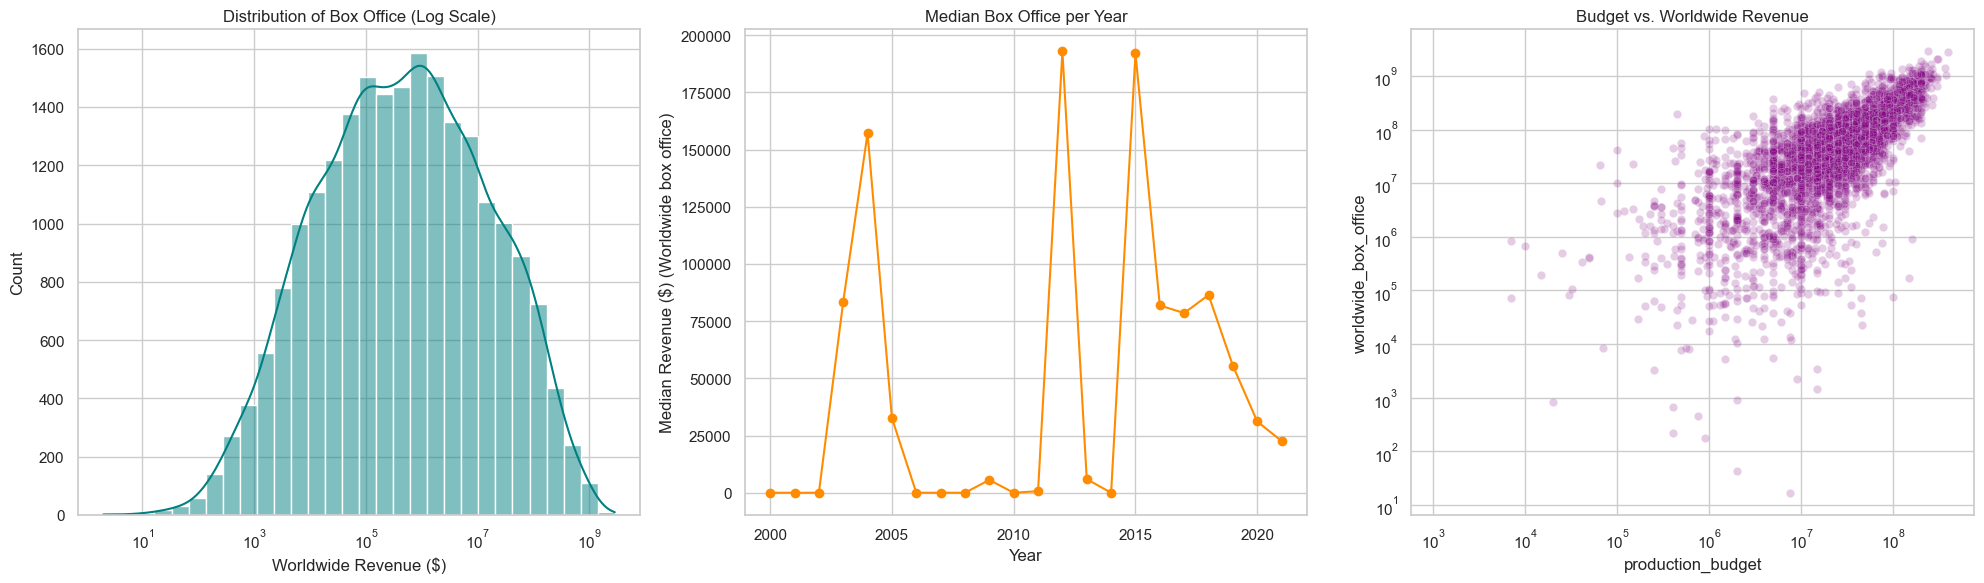

In [30]:
# Set the style for a professional look. Code by Muayyad 
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots in 1 row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribution of Worldwide Box Office (Log Scale)
# This shows us the scale of the movies—most are small, few are blockbusters.
sns.histplot(df_sales[df_sales['worldwide_box_office'] > 0]['worldwide_box_office'], 
             bins=30, kde=True, ax=axes[0], log_scale=True, color='teal')
axes[0].set_title('Distribution of Box Office (Log Scale)')
axes[0].set_xlabel('Worldwide Revenue ($)')

# 2. Box Office Trends Over Time
# Shows how the industry has grown from the 30k records.
yearly_revenue = df_sales.groupby('year')['worldwide_box_office'].median()
axes[1].plot(yearly_revenue.index, yearly_revenue.values, marker='o', color='darkorange')
axes[1].set_title('Median Box Office per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median Revenue ($) (Worldwide box office)')

# 3. Production Budget vs. Worldwide Box Office
# A scatter plot to see the correlation between spending and earning.
sns.scatterplot(data=df_sales[df_sales['production_budget'] > 0], 
                x='production_budget', y='worldwide_box_office', 
                alpha=0.2, ax=axes[2], color='purple')
axes[2].set_title('Budget vs. Worldwide Revenue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

1. The first graph shows that the market is dominated by a few successful movies (Blockbusters).
2. In the second graph we used the median to eleminate the effect of outliers, the decline around the year 2020 is consistent with the global impact of covid pandemic. (we'll investigate or drop the 0 values going further)
3. The last chart shows that there is a correlation between budget and world wide box office, but there is also a big variation, meaning that we need to look at other factors like "reviews" and "genres" to predict a blockbuster with our AI models.


---

## 5. Outlier Analysis and Distribution Normalisation

This section examines the presence and impact of extreme values in key numerical variables related to movie production and financial performance. Variables such as runtime, production budget, and worldwide box office revenue are known to exhibit substantial right-skewness, driven by a small number of exceptionally long films, high-budget productions, and blockbuster releases.

Boxplots are used to visually identify outliers and assess the degree of dispersion in these variables. While these extreme observations represent valid real-world phenomena rather than data errors, they can disproportionately influence statistical analyses and machine learning models, particularly those that rely on distance measures or assume approximately symmetric distributions.

To mitigate the effect of heavy-tailed distributions, logarithmic transformations are applied to selected financial variables. These transformations reduce skewness, compress extreme values, and stabilise variance, thereby improving numerical conditioning and model robustness. In addition, aggregated revenue analyses by genre and creative type provide contextual insight into structural drivers of financial performance, supporting informed feature selection in subsequent modelling stages.

Overall, this step ensures that key numerical features are appropriately scaled and transformed, enabling more reliable model training and interpretation while preserving the economic meaning of extreme but informative observations.

---


In [31]:
df_sales.describe() # Check max and min values with other descriptive stats. Code by Muayyad
# We have alot of 0 values in the financial columns, we'll deal with those later

,year,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg run per theatre,runtime
count,30612.000000,3.061200e+04,3.061200e+04,3.061200e+04,3.061200e+04,3.061200e+04,30612.000000,30612.000000,30612.000000
mean,2014.542108,1.117938e+07,6.736796e+06,1.779449e+07,5.330337e+06,1.959509e+06,258.978864,1.475637,81.432510
std,5.525085,5.637501e+07,3.258674e+07,8.555226e+07,2.193872e+07,1.010640e+07,822.519496,2.846537,47.198945
min,2000.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,2012.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,77.000000
50%,2016.000000,4.178200e+04,0.000000e+00,5.429850e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,93.000000
75%,2019.000000,1.414180e+06,7.326450e+04,1.957475e+06,0.000000e+00,1.000075e+04,2.000000,2.300000,106.000000
max,2021.000000,2.085392e+09,9.366622e+08,2.845900e+09,4.000000e+08,3.571150e+08,4725.000000,88.400000,2020.000000


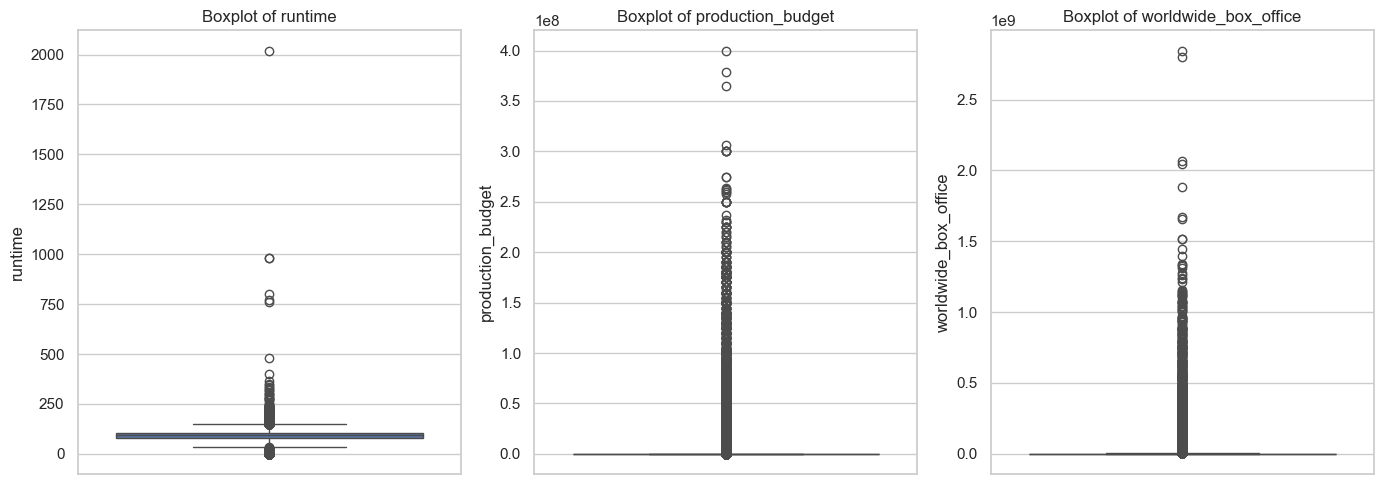

In [32]:
#  Visualize outliers using boxplots ------ Ahmed
#numeric_cols = ['runtime', 'production_budget', 'worldwide_box_office']
numeric_cols = ['runtime', 'production_budget', 'worldwide_box_office'] # specify the numerical columns to analyze

plt.figure(figsize=(14, 5))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_sales[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()
# Observations:
# Runtime:few movies have extremely long runtimes, which could skew analyses
# production_budget:several movies with very high budgets, indicating potential outliers
# worldwide_box_office:few movies with exceptionally high box office earnings
# -----These outliers need to be addressed before modeling-----

The boxplots:
reveal extreme values, particularly for budget and box office revenue. These represent blockbuster movies rather than data errors. Removing them would eliminate meaningful observations, therefore a logarithmic transformation is applied to reduce skewness while preserving relative differences.
Ahmed


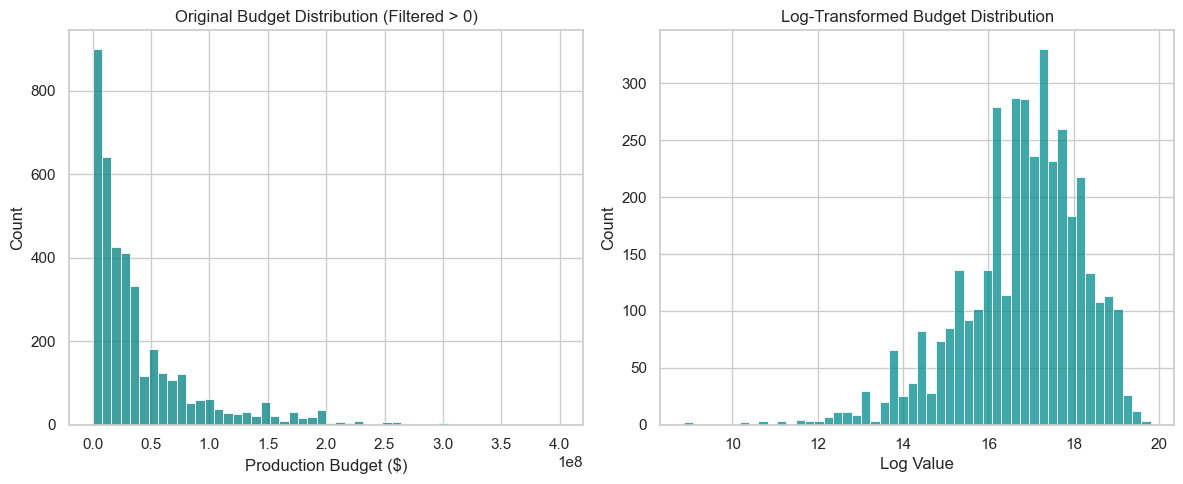

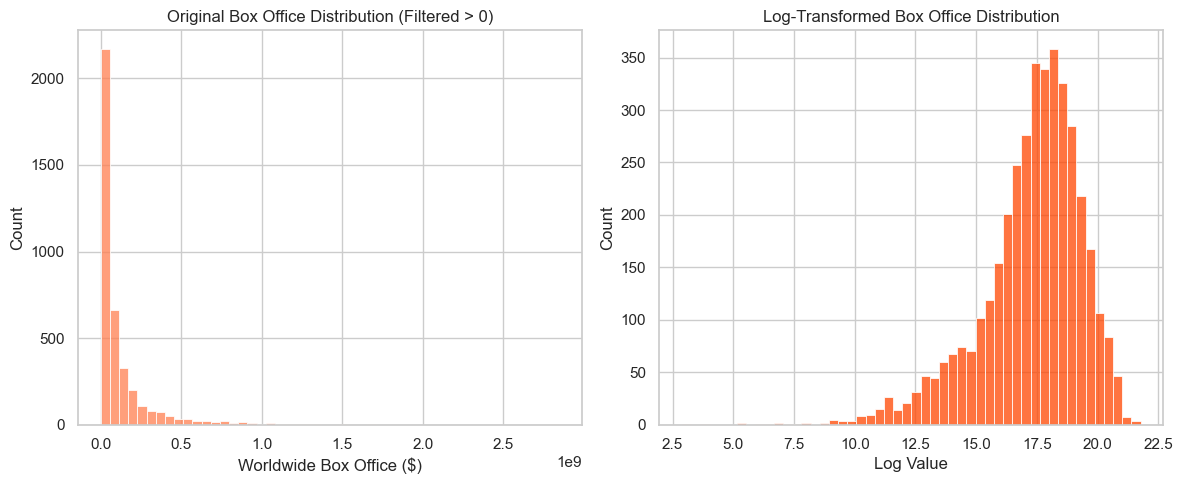

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for valid financial data (Both Budget and Box Office must be > 0) for better visibility, we'll deal with the 0 values later
# We create a specific dataframe for plotting to avoid changing the master data
df_plot = df_sales[(df_sales['production_budget'] > 0) & 
                   (df_sales['worldwide_box_office'] > 0)].copy()

# Apply Log transformation to the filtered data
# We use np.log1p which calculates log(1 + x) for better numerical stability
df_plot['log_production_budget'] = np.log1p(df_plot['production_budget'])
df_plot['log_worldwide_box_office'] = np.log1p(df_plot['worldwide_box_office'])

#  Visualization 1: Production Budget
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_plot['production_budget'], bins=50, color='teal')
plt.title('Original Budget Distribution (Filtered > 0)')
plt.xlabel('Production Budget ($)')

plt.subplot(1, 2, 2)
sns.histplot(df_plot['log_production_budget'], bins=50, color='darkcyan')
plt.title('Log-Transformed Budget Distribution')
plt.xlabel('Log Value')

plt.tight_layout()
plt.show()

#  Visualization 2: Worldwide Box Office
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_plot['worldwide_box_office'], bins=50, color='coral')
plt.title('Original Box Office Distribution (Filtered > 0)')
plt.xlabel('Worldwide Box Office ($)')

plt.subplot(1, 2, 2)
sns.histplot(df_plot['log_worldwide_box_office'], bins=50, color='orangered')
plt.title('Log-Transformed Box Office Distribution')
plt.xlabel('Log Value')

plt.tight_layout()
plt.show()

C:\Users\md-ra\AppData\Local\Temp\ipykernel_35468\770009325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
C:\Users\md-ra\AppData\Local\Temp\ipykernel_35468\770009325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')


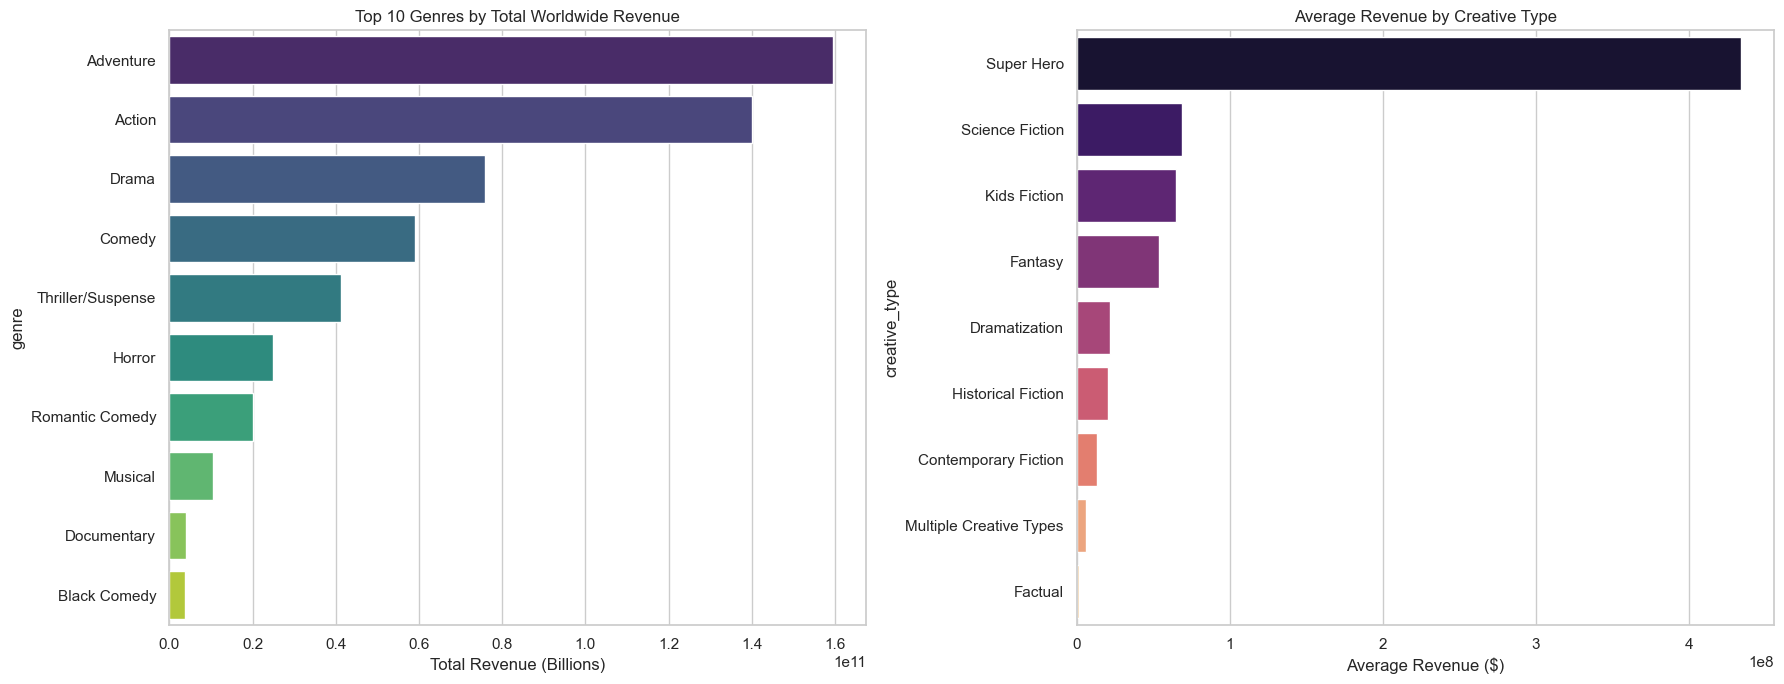

In [34]:
# Creating a figure with 2 subplots side-by-side for the two features that we see important. Code by Muayyad 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 Genres by total revenue
top_genres = df_sales.groupby('genre')['worldwide_box_office'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Total Worldwide Revenue')
axes[0].set_xlabel('Total Revenue (Billions)')

# Average revenue by creative type
creative_type = df_sales.groupby('creative_type')['worldwide_box_office'].mean().sort_values(ascending=False)
sns.barplot(x=creative_type.values, y=creative_type.index, ax=axes[1], palette='magma')
axes[1].set_title('Average Revenue by Creative Type')
axes[1].set_xlabel('Average Revenue ($)')

plt.tight_layout()
plt.show()

The categorical analysis reveals that Adventure and Action genres lead in total market volume, while the Super Hero creative type is the strongest individual indicator of high average revenue. These two key features will be very useful to detect blockbusters in the AI model.


Creating a master table that has all the required features to be used for AI modeling in a way that answers the business question:

In [35]:
# Data cleaning, and reviews aggregation, this will be used to add new features when making a master table. Code by Muayyad 

# Changing data types to numbers for some numerical columns in user and expert reviews dataframes:
df_user['idvscore'] = pd.to_numeric(df_user['idvscore'], errors='coerce')
df_expert['idvscore'] = pd.to_numeric(df_expert['idvscore'], errors='coerce')
df_user['thumbsUp'] = pd.to_numeric(df_user['thumbsUp'], errors='coerce')
df_user['thumbsTot'] = pd.to_numeric(df_user['thumbsTot'], errors='coerce')

# Aggregate one row per URL for user reviews:
user_agg = df_user.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count','thumbsUp': 'sum','thumbsTot': 'sum'}).reset_index()
user_agg.columns = ['url', 'user_idvscore_avg', 'user_rev_count','user_thumbsUp_tot', 'user_thumbsTot_tot']

# Create the Thumbs Down column using formula: thumbstot-thumbsup and dropping thumbs total (we keep only negative and positive)
user_agg['user_thumbsDown_tot'] = user_agg['user_thumbsTot_tot'] - user_agg['user_thumbsUp_tot']
user_agg = user_agg.drop(columns=['user_thumbsTot_tot'])

# Aggregate one row per URL for expert reviews:
expert_agg = df_expert.groupby('url').agg({'idvscore': 'mean', 'Rev': 'count'}).reset_index()
expert_agg.columns = ['url', 'expert_score_avg', 'expert_rev_count']


In [36]:
# Creating the master table. Code by Muayyad 

# Standardize titles for the merge
df_sales['title_clean'] = df_sales['title'].str.lower().str.strip()
df_meta['title_clean'] = df_meta['title'].str.lower().str.strip()

# Merge Meta and Sales
df_master = pd.merge(
    df_meta, 
    df_sales, 
    on=['title_clean', 'year'], 
    how='inner', 
    suffixes=('', '_sales')
)

# Join the aggregated reviews tables
df_master = pd.merge(df_master, user_agg, on='url', how='left')
df_master = pd.merge(df_master, expert_agg, on='url', how='left')


# MERGE EXPERT + USER EMBEDDINGS (Produced by transformer on URL)
features_merged = pd.merge(
    expert_features,
    user_features,
    on='url',
    how='inner'
)

df_master = pd.merge(
    df_master,
    features_merged,
    on='url',
    how='left'
)


# Create unique Movie ID
df_master['movie_id'] = range(1, len(df_master) + 1)

# Handle missing review data by filling NaNs with 0 (this is useful for the AI model)
review_cols = [
    'user_idvscore_avg', 'user_rev_count', 'user_thumbsUp_tot', 
    'user_thumbsDown_tot', 'expert_score_avg', 'expert_rev_count'
]
df_master[review_cols] = df_master[review_cols].fillna(0)

# Final cleanup of duplicated columns
if 'title_sales' in df_master.columns:
    df_master.drop(columns=['title_sales'], inplace=True)

print(f"New Master Table created with {len(df_master)} movies.")
df_master[['title', 'year', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 'worldwide_box_office']].head()

New Master Table created with 8025 movies.


,title,year,user_thumbsUp_tot,user_thumbsDown_tot,worldwide_box_office
0,10 Cloverfield Lane,2016,390.0,535.0,108286422.0
1,10 Years,2012,1.0,1.0,987640.0
2,100 Bloody Acres,2013,0.0,0.0,0.0
3,"10,000 km",2015,0.0,0.0,20452.0
4,1001 Grams,2015,0.0,0.0,47019.0


In [37]:
df_master.head(5)

,url,title,studio,rating,runtime,cast,director,genre,summary,awards,...,user_svd_41,user_svd_42,user_svd_43,user_svd_44,user_svd_45,user_svd_46,user_svd_47,user_svd_48,user_svd_49,movie_id
0,https://www.metacritic.com/movie/10-cloverfiel...,10 Cloverfield Lane,Paramount Pictures,PG-13,104.0,"John Gallagher Jr.,John Goodman,Mary Elizabeth...",Dan Trachtenberg,"Action,Sci-Fi,Drama,Mystery,Thriller,Horror","Waking up from a car accident, a young woman (...","#18MostDiscussedMovieof2016 , #1MostSharedMovi...",...,0.380989,-0.004147,0.641099,-0.012493,-0.733883,1.098561,-0.224419,0.793041,0.041966,1
1,https://www.metacritic.com/movie/10-years,10 Years,Anchor Bay Entertainment,R,100.0,"Channing Tatum,Chris Pratt,Jenna Dewan",Jamie Linden,"Drama,Comedy,Romance",No summary available,NaN,...,0.528378,-0.944050,0.969688,-1.200889,-0.578715,0.898690,1.037843,-0.509304,0.341109,2
2,https://www.metacritic.com/movie/100-bloody-acres,100 Bloody Acres,Music Box Films,Not Rated,91.0,Unknown,Cameron Cairnes,"Horror,Comedy",Reg and Lindsay run an organic fertilizer busi...,NaN,...,0.778435,-1.947314,1.723504,1.233509,0.771137,-1.107752,2.674029,-1.479069,0.429038,3
3,https://www.metacritic.com/movie/10000-km,"10,000 km",Broad Green Pictures,R,99.0,Unknown,Carlos Marques-Marcet,"Drama,Comedy,Romance","Two people in love, two apartments - one in Ba...",NaN,...,0.943959,0.419898,-0.807886,0.234847,2.409435,-0.070820,-1.826604,1.792671,0.020998,4
4,https://www.metacritic.com/movie/1001-grams,1001 Grams,Kino Lorber,Not Rated,93.0,Unknown,Bent Hamer,Drama,When Norwegian scientist Marie attends a semin...,NaN,...,-0.004974,-0.001025,-0.005785,0.007302,0.002498,-0.005972,-0.008778,0.003875,0.018414,5


In [38]:
# I want to add the movie ID back to the original dataframes as foreign key for better data integrity. Code by Muayyad 
# Create mapping with year and title
id_mapping = df_master[['title_clean', 'year', 'movie_id']].drop_duplicates()

# Add movie_id to df_sales
df_sales = pd.merge(df_sales, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to df_meta
df_meta = pd.merge(df_meta, id_mapping, on=['title_clean', 'year'], how='left')

# Add movie_id to the reviews datasets (using the 'url' which is unique)
# Create mapping with URL
url_mapping = df_master[['url', 'movie_id']].drop_duplicates()

df_user = pd.merge(df_user, url_mapping, on='url', how='left')
df_expert = pd.merge(df_expert, url_mapping, on='url', how='left')

df_sales.tail(4) # check


,year,release_date,title,genre,international_box_office,domestic_box_office,worldwide_box_office,production_budget,opening_weekend,theatre_count,avg run per theatre,runtime,keywords,creative_type,url,title_clean,movie_id
30650,2021,March,My Salinger Year,Drama,914119.0,54730.0,968849.0,0.0,28851.0,123.0,2.0,101.0,Set in New York City,Contemporary Fiction,https://www.the-numbers.com/movie/My-Salinger-...,my salinger year,4132.0
30651,2021,January,Escort Vehicle 36,Action,240000.0,0.0,240000.0,0.0,0.0,0.0,0.0,85.0,NaN,Historical Fiction,https://www.the-numbers.com/movie/Escort-Vehic...,escort vehicle 36,NaN
30652,2021,May,The Dry,Thriller/Suspense,16987526.0,364397.0,17351923.0,0.0,119364.0,186.0,2.5,118.0,Crime Thriller,Contemporary Fiction,https://www.the-numbers.com/movie/Dry-The-(Aus...,the dry,6096.0
30653,2021,January,Posledniy bogatyr. KorenÃ¢â‚¬â„¢ Zla,Adventure,33396899.0,0.0,33396899.0,0.0,0.0,0.0,0.0,0.0,NaN,Super Hero,https://www.the-numbers.com/movie/Posledniy-bo...,posledniy bogatyr. korenã¢â‚¬â„¢ zla,NaN


In [39]:
#print(df_master.columns)
# Check columns in df_master with all features
for i, column in enumerate(df_master.columns, 1):
    print(f"{i}. {column}")

1. url
2. title
3. studio
4. rating
5. runtime
6. cast
7. director
8. genre
9. summary
10. awards
11. metascore
12. userscore
13. RelDate
14. title_clean
15. year
16. release_date
17. genre_sales
18. international_box_office
19. domestic_box_office
20. worldwide_box_office
21. production_budget
22. opening_weekend
23. theatre_count
24. avg run per theatre
25. runtime_sales
26. keywords
27. creative_type
28. url_sales
29. user_idvscore_avg
30. user_rev_count
31. user_thumbsUp_tot
32. user_thumbsDown_tot
33. expert_score_avg
34. expert_rev_count
35. expert_sentiment_mean
36. expert_positive_ratio
37. expert_review_count
38. expert_svd_0
39. expert_svd_1
40. expert_svd_2
41. expert_svd_3
42. expert_svd_4
43. expert_svd_5
44. expert_svd_6
45. expert_svd_7
46. expert_svd_8
47. expert_svd_9
48. expert_svd_10
49. expert_svd_11
50. expert_svd_12
51. expert_svd_13
52. expert_svd_14
53. expert_svd_15
54. expert_svd_16
55. expert_svd_17
56. expert_svd_18
57. expert_svd_19
58. expert_svd_20
59. ex

---

## 5.2 Exploratory Data Analysis and Feature Engineering of the Master Table

Following the integration of sales data, metadata, and Transformer-derived review features, this section focuses on exploratory analysis and feature engineering applied to the consolidated master table. The objective of this stage is to prepare a modelling-ready dataset by ensuring appropriate data types, analysing relationships between key variables, and constructing informative features that capture both structural and behavioural aspects of movie success.

Categorical variables such as rating, genre, studio, release date, and creative type are explicitly converted to categorical data types to reflect their nominal nature and to facilitate subsequent encoding. Numerical variables representing financial outcomes, audience engagement, and review metrics are standardised to consistent numeric formats to ensure interpretability and mathematical validity.

Exploratory analysis is performed to identify the strongest predictors of worldwide box office performance. Correlation analysis and regression-based visualisations are used to examine relationships between production investment, review-based engagement indicators, and revenue outcomes. These analyses inform feature selection decisions and motivate the exclusion of variables that could introduce redundancy or data leakage, such as domestic and international box office figures when worldwide revenue is used as the target variable.

Feature engineering further refines the dataset by transforming multi-valued categorical attributes into structured numerical representations. In particular, genre information is decomposed into binary indicators for the most influential genres, alongside summary measures capturing genre diversity. This approach preserves interpretability while enabling machine learning models to exploit genre-specific effects.

Overall, this section establishes a principled transition from raw integrated data to a final modelling dataset. The resulting feature set balances predictive relevance, interpretability, and methodological rigor, providing a robust foundation for training and evaluating machine learning models to predict movie success.

---


In [40]:
# check data types and missing data. Code by Muayyad 
pd.concat([df_master.dtypes, df_master.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

,Data Type,Missing data count
url,object,0
title,object,0
studio,object,197
rating,object,0
runtime,float64,0
...,...,...
user_svd_46,float64,0
user_svd_47,float64,0
user_svd_48,float64,0
user_svd_49,float64,0


In [41]:
# Convert text columns we need to categorical.. Code by Muayyad 
df_master['rating'] = df_master['rating'].astype('category')
df_master['release_date'] = df_master['release_date'].astype('category') # because previously we only kept the year in this column
df_master['genre'] = df_master['genre'].astype('category')
df_master['studio'] = df_master['studio'].astype('category')
df_master['creative_type'] = df_master['creative_type'].astype('category')

# Convert floats to integers for columns that are "counts"
# better for the financial columns too since we have no decimal places
cols_to_int = ['production_budget', 'worldwide_box_office', 'theatre_count', 
               'user_thumbsUp_tot', 'user_thumbsDown_tot', 'metascore']

df_master[cols_to_int] = df_master[cols_to_int].astype('int64')

df_master.dtypes # check

url              object
title            object
studio         category
rating         category
runtime         float64
                 ...   
user_svd_46     float64
user_svd_47     float64
user_svd_48     float64
user_svd_49     float64
movie_id          int64
Length: 141, dtype: object

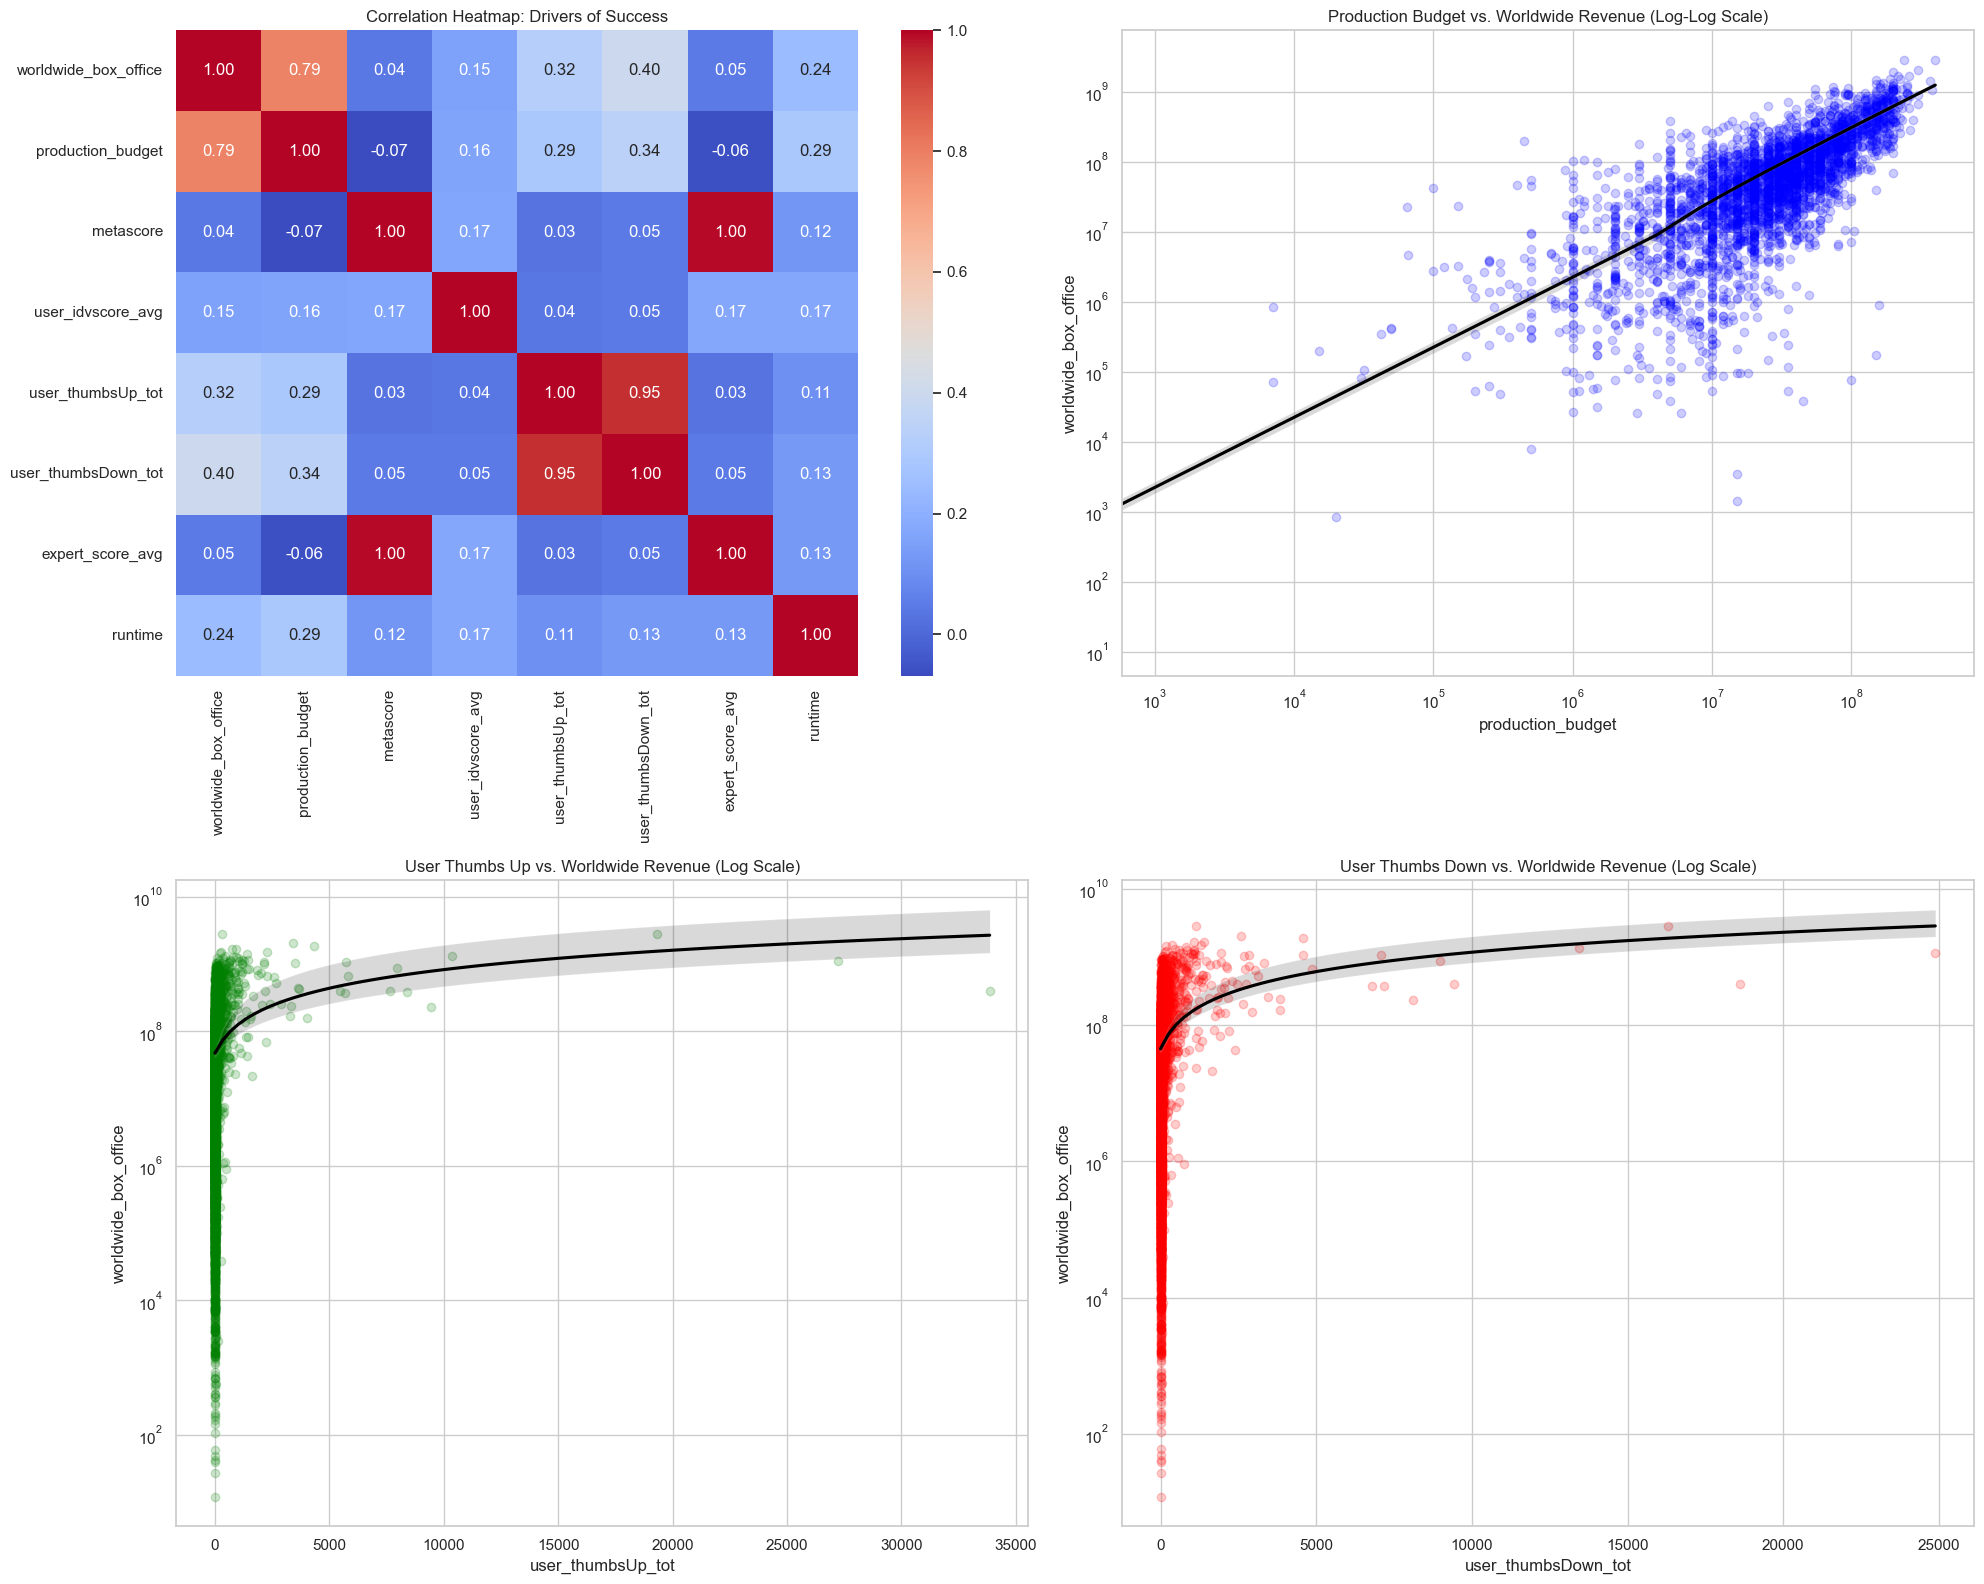

In [42]:
# Set up a 2x2 grid for a nicer visualization. Code by Muayyad 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Top-Left: Correlation Heatmap
cols_to_corr = [
    'worldwide_box_office', 'production_budget', 'metascore', 
    'user_idvscore_avg', 'user_thumbsUp_tot', 'user_thumbsDown_tot', 
    'expert_score_avg', 'runtime'
]
sns.heatmap(df_master[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0,0])
axes[0,0].set_title('Correlation Heatmap: Drivers of Success')

# Top-Right: Budget vs Revenue (Strongest Correlation: 0.79)
sns.regplot(data=df_master, x='production_budget', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'blue'}, line_kws={'color':'black'}, ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
axes[0,1].set_title('Production Budget vs. Worldwide Revenue (Log-Log Scale)')

# Bottom-Left: Thumbs Up vs Revenue
sns.regplot(data=df_master, x='user_thumbsUp_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'green'}, line_kws={'color':'black'}, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title('User Thumbs Up vs. Worldwide Revenue (Log Scale)')

# Bottom-Right: Thumbs Down vs Revenue
sns.regplot(data=df_master, x='user_thumbsDown_tot', y='worldwide_box_office', 
            scatter_kws={'alpha':0.2, 'color':'red'}, line_kws={'color':'black'}, ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('User Thumbs Down vs. Worldwide Revenue (Log Scale)')

plt.tight_layout()
plt.savefig('eda_master_grid.png')

The correlation heatmap shows that spending money on the budget is the most reliable way to predict how much money a movie will make.
Production budget has the most correlation with the world-wide-revenue.
Thumbs-up and Thumbs-down both represent engagement/audience reach, that means most successful movies get alot of hate, or love! but not necessarily high revenue.

---

## 6. Final Data Preparation for Predictive Modelling

This section prepares the consolidated feature set for predictive modelling by constructing a final, model-ready dataset and defining the target variable. The primary outcome of interest is worldwide box office revenue, which serves as a proxy for movie success. To ensure methodological validity, observations with non-positive worldwide box office values are separated from the training data and retained for later prediction using the trained models.

The preparation process addresses remaining data quality and modelling requirements. Categorical variables are standardised and imputed using principled strategies to ensure completeness while preserving interpretability. High-cardinality attributes that may hinder model performance, such as individual director identifiers, are transformed into lower-dimensional representations that capture informative signals, such as experience levels.

Finally, categorical features are encoded into numerical formats suitable for machine learning algorithms, and a comprehensive sanity check is performed to verify data types and dimensional consistency. This step results in a fully numerical, well-structured dataset that is free from data leakage and suitable for training and evaluating predictive models of movie success.

---


In [43]:
# Define the columns we want to keep. Code by Muayyad

expert_svd_cols = [c for c in df_master.columns if c.startswith("expert_svd_")]
user_svd_cols   = [c for c in df_master.columns if c.startswith("user_svd_")]


features_to_keep = [
    'worldwide_box_office', 'production_budget', 'theatre_count',
    'runtime', 'metascore', 'userscore', 'expert_score_avg',
    'user_thumbsUp_tot', 'user_thumbsDown_tot', 'user_rev_count',
    'rating', 'genre', 'release_date', 'year', 'creative_type', 'movie_id', 'director',
    'expert_review_count', 'expert_positive_ratio', 'expert_sentiment_mean',
    'user_review_count', 'user_positive_ratio', 'user_sentiment_mean'
] + expert_svd_cols + user_svd_cols

# Create the final modeling dataframe
df_final = df_master[features_to_keep].copy()

df_final.tail(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,...,user_svd_40,user_svd_41,user_svd_42,user_svd_43,user_svd_44,user_svd_45,user_svd_46,user_svd_47,user_svd_48,user_svd_49
8020,55348693,50000000,3394,102.0,34,4.1,40.261905,71,54,54,...,-0.432534,-0.960982,-0.219140,-0.363683,0.155026,0.078512,-0.522496,0.127516,0.148954,-0.825883
8021,12506188,35000000,2501,83.0,26,4.4,30.428571,10,12,21,...,-0.167859,-1.351379,-0.116376,-0.341076,0.784234,0.763516,-0.200449,-0.306757,0.546934,0.011952
8022,2784,0,0,96.0,55,5.7,56.875000,1,0,3,...,2.011536,0.434435,0.314743,0.793167,-0.811605,1.716392,0.423374,-0.254649,1.630320,0.271039
8023,1004629935,150000000,3827,108.0,78,8.6,78.093023,1186,740,276,...,0.021056,0.007785,0.310698,0.374557,0.665697,-0.798159,0.239473,0.093325,-0.362848,-0.280695
8024,0,0,2,106.0,50,7.2,53.555556,0,0,1,...,-2.657580,1.500850,-4.064957,2.307889,1.009904,0.866805,2.540218,3.185778,0.200703,0.228850


In [44]:
# Force Pandas to show all rows in the output so we can monitor all columns. Code by Muayyad
pd.set_option('display.max_rows', None) 
# we have to reset this back if we want to avoid long outputs use pd.reset_option('display.max_rows')!!!!!

# Check datatypes and missing data count to spot missing data
verification_df = pd.concat([df_final.dtypes, df_final.isna().sum()], axis=1, keys=['Data Type', 'Missing data count'])

# Print the result
print(verification_df)

                      Data Type  Missing data count
worldwide_box_office      int64                   0
production_budget         int64                   0
theatre_count             int64                   0
runtime                 float64                   0
metascore                 int64                   0
userscore               float64                   0
expert_score_avg        float64                   0
user_thumbsUp_tot         int64                   0
user_thumbsDown_tot       int64                   0
user_rev_count            int64                   0
rating                 category                   0
genre                  category                   8
release_date           category                   0
year                      int32                   0
creative_type          category                 656
movie_id                  int64                   0
director                 object                   0
expert_review_count       int64                   0
expert_posit

In [45]:
# We found 8 missing genres, and 656 creative_types. Code by Muayyad

# Filter the dataframe to show only rows where 'genre' is NaN
missing_genres = df_final[df_final['genre'].isna()]

# Show the title and financial columns to identify these movies
print(missing_genres[['genre','worldwide_box_office', 'production_budget']])

     genre  worldwide_box_office  production_budget
1326   NaN                     0                  0
1757   NaN                     0                  0
2096   NaN                     0                  0
6211   NaN                     0                  0
7047   NaN                     0                  0
7231   NaN                     0                  0
7404   NaN                     0                  0
7875   NaN                     0                  0


In [46]:
# 1. Drop rows where 'genre' is missing, not important since they also have no production budget or Worldwide bo. Code by Muayyad
df_final = df_final.dropna(subset=['genre'])

# Quick check to confirm 0 missing values remain
print(f"Remaining missing genres: {df_final['genre'].isna().sum()}")

Remaining missing genres: 0


In [47]:
# Filter the dataframe to show only rows where 'creative type' is NaN. Code by Muayyad
missing_creative = df_final[df_final['creative_type'].isna()]

# Show the title and financial columns to identify these movies
print(missing_creative[['creative_type','worldwide_box_office', 'production_budget']])

     creative_type  worldwide_box_office  production_budget
44             NaN                 42629                  0
74             NaN                     0                  0
103            NaN                315305                  0
127            NaN                     0                  0
151            NaN                     0                  0
154            NaN                     0                  0
169            NaN                     0                  0
170            NaN                983499                  0
193            NaN                     0                  0
195            NaN                     0            5250000
197            NaN                     0                  0
201            NaN                     0                  0
211            NaN                     0                  0
217            NaN                     0                  0
233            NaN                     0            6500000
236            NaN                     0

In [ ]:
# Since creative_type is an important feature,
# We impute the missing values with "Unknown" since they are less that 15% and some values already have BO numbers. Code by Muayyad 

# Switch data type from Categorical to String to be able to change the value to something else.
df_final['creative_type'] = df_final['creative_type'].astype(str)

# Fill missing values with 'Unknown'
df_final['creative_type'] = df_final['creative_type'].replace('nan', 'Unknown').fillna('Unknown')

# Switch back to Categorical type
df_final['creative_type'] = df_final['creative_type'].astype('category')

# Quick check to confirm 0 missing values remain
print(f"Remaining missing creative types: {df_final['creative_type'].isna().sum()}")
# Verify 'Unknown' is now a valid category
print(f"Categories available: {df_final['creative_type'].unique().tolist()}")

Remaining missing creative types: 0
Categories available: ['Contemporary Fiction', 'Kids Fiction', 'Dramatization', 'Historical Fiction', 'Factual', 'Science Fiction', 'Unknown', 'Fantasy', 'Multiple Creative Types', 'Super Hero']


Worldwide_box_office will be our target (Y) and the others are our features (X).
We'll make some more feature engineering below:

In [49]:
# checking how many times each genre appears in the dataset, split the coma seperated genres (extracted initially from meta table). Code by Muayyad 
df1 = df_final['genre_list'] = df_final['genre'].str.split(',')
df1 = df_final.explode('genre_list') # this expands the list of genres to seperate rows for each movie so we can count them later.


In [50]:
df1.shape # To see how many rows it has expanded to just out of curiosity :) 

(19682, 124)

In [51]:
# Group genres to see the most frequent ones. Code by Muayyad 
df1.groupby('genre_list')['genre_list'].count().sort_values(ascending=False)

genre_list
Drama          4283
Comedy         2504
Thriller       1944
Documentary    1371
Romance        1277
Action         1086
Crime           972
Adventure       836
Horror          723
Mystery         630
Biography       608
Fantasy         547
Sci-Fi          532
Family          528
Music           418
History         372
Animation       277
War             270
Sport           233
Musical         128
Western          76
News             52
Short             8
Adult             7
Name: genre_list, dtype: int64

In [52]:
# We'll select the first 10 genres, because from our initial EDA we know that Adventure is the most successful genre, so it is important for the prediction. Code by Muayyad 
# Prepare the list and the Top 10 Target Genres
df_final['genre_list'] = df_final['genre'].astype(str).str.split(',')
main_genres = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 
    'Documentary', 'Adventure', 'Horror', 'Crime', 'Sci-Fi'
]

# this piece of code was enhanced with AI instead of the very long logic we used
for g in main_genres:
    # Clean the genre name for the column header (remove spaces/dashes)
    col_name = f'is_{g.lower().replace(" ", "_").replace("-", "_")}'
    
    # Check if the genre exists in the list for each row
    # .apply handles the list check; .astype(int) turns True/False into 1/0
    df_final[col_name] = df_final['genre_list'].apply(lambda x: g in [i.strip() for i in x]).astype('int64')

# Add "is_other_genre" (count of genres NOT in our top 10)
df_final['is_other_genre'] = df_final['genre_list'].apply(
    lambda x: len([i.strip() for i in x if i.strip() not in main_genres])
).astype('int64')

# Add "nr_genres" (total count of genres for that movie)
df_final['nr_genres'] = df_final['genre_list'].apply(lambda x: len(x)).astype('int64')

# Drop the temporary list column and the genre (the source column after encoding) to keep df_final clean
df_final = df_final.drop(columns=['genre_list','genre'])

print("Top 10 Genre features created successfully!")
print(df_final.filter(like='is_').head())

Top 10 Genre features created successfully!
   is_drama  is_comedy  is_thriller  is_action  is_romance  is_documentary  \
0         1          0            1          1           0               0   
1         1          1            0          0           1               0   
2         0          1            0          0           0               0   
3         1          1            0          0           1               0   
4         1          0            0          0           0               0   

   is_adventure  is_horror  is_crime  is_sci_fi  is_other_genre  
0             0          1         0          1               1  
1             0          0         0          0               0  
2             0          1         0          0               0  
3             0          0         0          0               0  
4             0          0         0          0               0  


In [53]:
# Create season map to create a new feature for the season.. Code by Muayyad 
season_map = {
    'January': 'Winter', 'February': 'Winter', 'December': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}

# Map the seasons into df_final 
# (We use .str.strip() just in case there are hidden spaces in the month names)
df_final['season'] = df_final['release_date'].str.strip().map(season_map)

# One-Hot Encode the seasons (Convert to is_summer, is_winter, etc.)
season_dummies = pd.get_dummies(df_final['season'], prefix='is_season').astype('int64')

# Join the new columns and drop the original text 'season' and 'release_date'
df_final = pd.concat([df_final, season_dummies], axis=1)
df_final = df_final.drop(columns=['season', 'release_date'])

print(df_final.filter(like='is_season').head())

   is_season_Autumn  is_season_Spring  is_season_Summer  is_season_Winter
0                 0                 1                 0                 0
1                 1                 0                 0                 0
2                 0                 0                 1                 0
3                 0                 0                 1                 0
4                 0                 1                 0                 0


In [54]:
df_final.head(5)

,worldwide_box_office,production_budget,theatre_count,runtime,metascore,userscore,expert_score_avg,user_thumbsUp_tot,user_thumbsDown_tot,user_rev_count,...,is_adventure,is_horror,is_crime,is_sci_fi,is_other_genre,nr_genres,is_season_Autumn,is_season_Spring,is_season_Summer,is_season_Winter
0,108286422,15000000,3391,104.0,76,7.7,75.744186,390,535,201,...,0,1,0,1,1,6,0,1,0,0
1,987640,0,3,100.0,61,6.9,62.666667,1,1,7,...,0,0,0,0,0,3,1,0,0,0
2,0,0,13,91.0,63,7.5,65.800000,0,0,2,...,0,1,0,0,0,2,0,0,1,0
3,20452,0,0,99.0,75,7.4,75.166667,0,0,2,...,0,0,0,0,0,3,0,0,1,0
4,47019,0,0,93.0,65,0.0,67.000000,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [55]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8017 entries, 0 to 8024
Columns: 137 entries, worldwide_box_office to is_season_Winter
dtypes: category(2), float64(107), int32(1), int64(26), object(1)
memory usage: 8.3+ MB


In [56]:
# check Nan values vs "0" in Runtime to impute
nan_count = df_final['runtime'].isna().sum()
zero_count = (df_final['runtime'] == 0).sum()

print(f"Number of Nan values: {nan_count}")
print(f"Number of 0.0 runtimes: {zero_count}")

Number of Nan values: 0
Number of 0.0 runtimes: 164


In [ ]:
df_final = df_final.reset_index(drop=True) # this was added while debugging, we dropped few columns before so we reset index

In [60]:
# Flag the rows that are missing runtime so we can look at them later. Code by Muayyad 
missing_mask = (df_final['runtime'] == 0) | (df_final['runtime'].isna())

# Convert the 0.0 values to NaN for the imputer
df_final['runtime'] = df_final['runtime'].replace(0, np.nan)

# Select columns to take into consideration # code enhanced with AI instead of the manual naming of the previously encoded columns
impute_cols = ['runtime', 'production_budget'] + [col for col in df_final.columns if 'is_' in col]

# Initialize and run the Imputer, we'll check the nearest 3 neighbours
imputer = KNNImputer(n_neighbors=3)
df_temp = pd.DataFrame(imputer.fit_transform(df_final[impute_cols]), columns=impute_cols)

# We create a small table showing the "Before" (which was 0/NaN) and the "After"
verification_df = pd.DataFrame({
    'Old_Runtime': 0, # this was changed to 0 earlier when we were changing data types
    'Imputed_Runtime': df_temp.loc[missing_mask,'runtime'].values
})

print("Check the imputation")
print(verification_df.head(10)) 
# We'll see if the numbers look realistic (for example, 90, 105, 120)




Check the imputation
   Old_Runtime  Imputed_Runtime
0            0        93.000000
1            0        82.000000
2            0        87.333333
3            0       108.000000
4            0       116.666667
5            0       116.000000
6            0       101.333333
7            0        85.000000
8            0       108.000000
9            0        91.000000


In [61]:
# The numbers actually look realistic. Code by Muayyad 
# Put the verified runtimes back into df_final
df_final['runtime'] = df_temp['runtime'].values

# Final cleanup: round to whole minutes
df_final['runtime'] = df_final['runtime'].round(0).astype('int64')

del df_temp

print("Final check number of zeros =", (df_final['runtime'] == 0).sum())

Final check number of zeros = 0


# Preparing for modelling

we'll create a new table called df_final_clean that has values greater than 0 for world wide box office, and move the ones that has 0 values to another dataframe to predict them later

In [62]:
df_ready = df_final.copy()

In [64]:
# --------------------------------------------------
# STEP 2: Target variable
# --------------------------------------------------

y = df_ready['worldwide_box_office']

print("Target min:", y.min())
print("Target max:", y.max())
print("Target missing values:", y.isna().sum())

Target min: 0
Target max: 2845899541
Target missing values: 0


In [65]:
# ==============================
# CLEAN RATING
# ==============================

rating_map = {
    'Not Rated': 'Unrated',
    'NR': 'Unrated',
    'TV-MA': 'R',
    'TV-14': 'PG-13',
    'TV-G': 'G',
    'TV-PG': 'PG'
}

df_ready['rating'] = (
    df_ready['rating']
    .replace(rating_map)
    .fillna('Unrated')
)

print("Rating distribution after cleaning:")
print(df_ready['rating'].value_counts())
print("-" * 50)

Rating distribution after cleaning:
rating
R           2937
Unrated     2522
PG-13       1746
PG           670
G             99
NC-17         31
Open           4
PG--13         4
Approved       2
M/PG           1
MA-17          1
Name: count, dtype: int64
--------------------------------------------------


C:\Users\md-ra\AppData\Local\Temp\ipykernel_35468\3237346415.py:16: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rating_map)


In [66]:
# ==============================
# FIX DIRECTOR
# Convert director identity → experience signal
# ==============================

# Count how many movies each director has
director_counts = df_ready['director'].value_counts()

# Map experience buckets
df_ready['director_bucket'] = df_ready['director'].map(
    lambda x:
        'new_director' if director_counts.get(x, 0) == 1 else
        'low_exp' if director_counts.get(x, 0) <= 3 else
        'mid_exp' if director_counts.get(x, 0) <= 10 else
        'high_exp'
)

# Drop high-cardinality original column
df_ready = df_ready.drop(columns=['director'])

print("Director experience buckets:")
print(df_ready['director_bucket'].value_counts())
print("-" * 50)




Director experience buckets:
director_bucket
new_director    3083
low_exp         2438
mid_exp         2235
high_exp         261
Name: count, dtype: int64
--------------------------------------------------


In [67]:
# ==============================
# ONE-HOT ENCODING
# ==============================

df_ready = pd.get_dummies(
    df_ready,
    columns=['rating', 'creative_type', 'director_bucket'],
    drop_first=True
)

print("Encoding complete.")
print("Final shape:", df_ready.shape)
print("-" * 50)

# ==============================
# FINAL SANITY CHECK
# ==============================

print("Dtype summary:")
print(df_ready.dtypes.value_counts())


print("STEP 3 COMPLETED — DATA IS CLEAN & MODEL-READY")

Encoding complete.
Final shape: (8017, 156)
--------------------------------------------------
Dtype summary:
float64    106
int64       27
bool        22
int32        1
Name: count, dtype: int64
STEP 3 COMPLETED — DATA IS CLEAN & MODEL-READY


In [68]:
# --------------------------------------------------
# Drop identifier
# --------------------------------------------------

df_ready = df_ready.drop(columns=['movie_id'])

In [69]:
# --------------------------------------------------
#  Feature / target split
# --------------------------------------------------

X = df_ready.drop(columns=['worldwide_box_office'])
y = df_ready['worldwide_box_office']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8017, 154)
y shape: (8017,)


In [70]:
# --------------------------------------------------
# Convert boolean columns to 0/1
# --------------------------------------------------

bool_cols = df_ready.select_dtypes(include='bool').columns
df_ready[bool_cols] = df_ready[bool_cols].astype(int)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"Converted {len(bool_cols)} boolean columns to int.")

print("Boolean columns converted in df_final.")

Converted 22 boolean columns to int.
Boolean columns converted in df_final.


In [150]:
# --------------------------------------------------
# Final checks
# --------------------------------------------------
#
print(X.dtypes.value_counts())
print("Total missing values:", X.isna().sum().sum())

# assert X.isna().sum().sum() == 0, "Missing values still exist!"
# assert len(X.select_dtypes(exclude=[np.number]).columns) == 0, \
#     "Non-numeric columns remain!"

print("FINAL CHECK PASSED — DATA IS MODEL-READY")

float64    106
int64       46
int32        1
Name: count, dtype: int64
Total missing values: 0
FINAL CHECK PASSED — DATA IS MODEL-READY


In [151]:
# Now, I want to remove the movies that have 0 world wide box office and move them to another table. Code by Muayyad 
# Create a table with only movies that have a box office greater than 0
df_final_clean = df_ready[df_ready['worldwide_box_office'] > 0].copy()

# Move the rows with 0 box office to a separate "Zero Box Office" table
df_zero_box_office = df_ready[df_ready['worldwide_box_office'] == 0].copy()

# Verification
print(f"Movies with valid Box Office data: {df_final_clean.shape[0]}")
print(f"Movies moved to the Zero Table: {df_zero_box_office.shape[0]}")

# Check the minimum value in our new clean table to be sure
print(f"New minimum Box Office: ${df_final_clean['worldwide_box_office'].min()}")

Movies with valid Box Office data: 5081
Movies moved to the Zero Table: 2944
New minimum Box Office: $12


In [152]:
# --------------------------------------------------
# Save datasets
# --------------------------------------------------

import os

output_dir = "../final_data"
os.makedirs(output_dir, exist_ok=True)

# Training data
df_final_clean.to_csv(
    os.path.join(output_dir, "final_modeling_dataset.csv"),
    index=False
)

# Prediction data
df_zero_box_office.to_csv(
    os.path.join(output_dir, "zero_box_office_dataset.csv"),
    index=False
)

# Full master backup
df_master.to_csv(
    os.path.join(output_dir, "master_merged_dataset.csv"),
    index=False
)

print("FILES SAVED SUCCESSFULLY")
print("Final modeling dataset:", df_final_clean.shape)
print("Zero box office dataset:", df_zero_box_office.shape)
print("Master dataset:", df_master.shape)


FILES SAVED SUCCESSFULLY
Final modeling dataset: (5081, 154)
Zero box office dataset: (2944, 154)
Master dataset: (8025, 143)


---

### 7. Target Variable Transformation: Worldwide Box Office Performance

The worldwide box office revenue is characterised by a highly right-skewed distribution, in which a small number of movies generate disproportionately large revenues compared to the majority of releases. Directly modelling this variable as a continuous outcome can lead to unstable regression models that are overly influenced by extreme values and exhibit poor generalisation.

To address this challenge, the prediction task is reformulated as a classification problem by discretising worldwide box office revenue into economically meaningful success categories. A two-stage quantile-based bucketing strategy is applied. First, movies in the top 10% of worldwide box office revenue are assigned to a dedicated **Blockbuster** class, ensuring that extreme but commercially significant outcomes are explicitly preserved rather than diluted or removed. Second, the remaining 90% of movies are partitioned into three balanced performance groups (**Low**, **Medium**, and **High**) using quantile-based thresholds to maintain comparable class sizes.

This transformation reduces variance, improves numerical stability, and mitigates the influence of extreme outliers while retaining the full spectrum of revenue outcomes. By mapping continuous financial performance to discrete success tiers, the target variable aligns more closely with business-oriented decision-making and enables robust comparison of classification models in subsequent stages of the analysis.

---


Blockbuster threshold (top 10%): 217,194,805


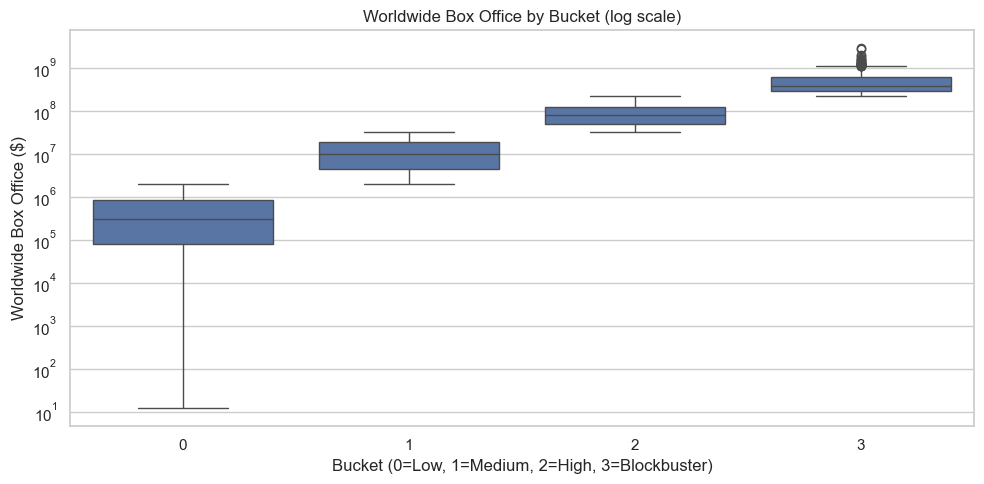

In [153]:
#Stage 1: managing the predicted variable Y ---------------------------------Ahmed



# 0. blockbuster threshold
y_raw = df_final_clean['worldwide_box_office']

blockbuster_threshold = y_raw.quantile(0.90)
print(f"Blockbuster threshold (top 10%): {blockbuster_threshold:,.0f}")

# Create y_bucket as a nullable integer column (no dtype issues)
df_final_clean['y_bucket'] = pd.Series(pd.NA, index=df_final_clean.index, dtype="Int64")

# 1. Assign blockbuster class
df_final_clean.loc[
    df_final_clean['worldwide_box_office'] >= blockbuster_threshold,
    'y_bucket'
] = 3

# 2. Bucket the remaining 90% into 3 balanced classes
mask_non_blockbuster = df_final_clean['y_bucket'].isna()

q = pd.qcut(
    df_final_clean.loc[mask_non_blockbuster, 'worldwide_box_office'],
    q=3,
    duplicates='drop'   # safe even without zeros
)

# Convert qcut bins to integer codes 0,1,2 and assign
df_final_clean.loc[mask_non_blockbuster, 'y_bucket'] = q.cat.codes.astype("Int64")

# 3. Final type as regular int & print buckets(optional)
df_final_clean['y_bucket'] = df_final_clean['y_bucket'].astype(int)
df_final_clean['y_bucket'].value_counts().sort_index()

#4. Visualize the buckets

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_final_clean, x='y_bucket', y='worldwide_box_office')
plt.yscale('log')  # revenue is skewed, log scale makes it readable
plt.title('Worldwide Box Office by Bucket (log scale)')
plt.xlabel('Bucket (0=Low, 1=Medium, 2=High, 3=Blockbuster)')
plt.ylabel('Worldwide Box Office ($)')
plt.tight_layout()
plt.show()

#4. Create a classification column for each movie (row)
bucket_map = {
    0: 'Low',
    1: 'Medium',
    2: 'High',
    3: 'Blockbuster'
}

df_final_clean['y_class'] = df_final_clean['y_bucket'].map(bucket_map)
#Verification by prinitng few rows
df_final_clean[['worldwide_box_office', 'y_bucket', 'y_class']].head(10)

#5. Fix the predicted variable y for modeling ------ Ahmed
y = df_final_clean['y_bucket']



Since the prediction task is formulated as a classification problem, the target variable is represented as discrete classes rather than continuous values. Therefore, scaling or normalization is applied only to predictor variables. No transformations are applied to the target labels.


Missing value percentage (%):
production_budget    0.0
runtime              0.0
dtype: float64


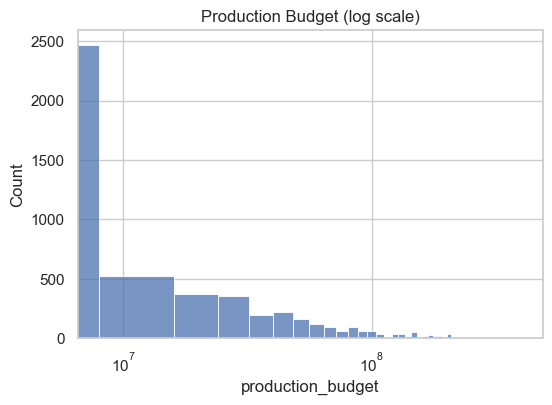

Number of zero budgets: 1886
Zeros: 1886
NaNs: 0
Total rows: 5081
99th percentile runtime cap: 159.19999999999982


,runtime,runtime_scaled,production_budget,log_budget,log_budget_scaled
count,5081.000000,5.081000e+03,5.081000e+03,5081.000000,5.081000e+03
mean,105.652824,6.607586e-16,3.661072e+07,16.951329,9.733079e-16
std,19.883656,1.000098e+00,4.003113e+07,1.104002,1.000098e+00
min,21.000000,-5.132893e+00,7.000000e+03,8.853808,-7.335417e+00
25%,94.000000,-6.905789e-01,2.000000e+07,16.811243,-1.269023e-01
50%,103.000000,-1.428964e-01,2.510000e+07,17.038378,7.885628e-02
75%,115.000000,5.873470e-01,3.500000e+07,17.370859,3.800449e-01
max,808.000000,3.277077e+00,4.000000e+08,19.806975,2.586884e+00


In [154]:
# Stage 2: managing some features (Production Budget & Runtime)-----------------Ahmed


#Checks of scale and value for budget and runtime ----------------------------------------------------------

cols_to_check = ['production_budget', 'runtime'] # runtime is already imputed

missing_stats = (
    df_final_clean[cols_to_check]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

print("Missing value percentage (%):")
print(missing_stats)

# Scale of production budget
df_final_clean[cols_to_check].describe()

plt.figure(figsize=(6,4))
sns.histplot(df_final_clean['production_budget'], bins=50)
plt.xscale('log')
plt.title('Production Budget (log scale)')
plt.show()


from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# scaling budget & log transform (Production Budget)--------------------------------------------------------Ahmed

# Check for any missing budgets
num_zeros = (df_final_clean['production_budget'] == 0).sum()
print(f"Number of zero budgets: {num_zeros}")
print("Zeros:", (df_final_clean['production_budget'] == 0).sum())
print("NaNs:", df_final_clean['production_budget'].isna().sum())
print("Total rows:", len(df_final_clean))

# Create missing indicator
df_final_clean['budget_missing'] = (df_final_clean['production_budget'] == 0).astype(int)
import numpy as np

# Replace zeros with NaN
df_final_clean['production_budget'] = df_final_clean['production_budget'].replace(0, np.nan)

# Log-transform (budget is highly skewed)
df_final_clean['log_budget'] = np.log1p(df_final_clean['production_budget'])

# Median imputation on log scale
imp = SimpleImputer(strategy='median')
df_final_clean[['log_budget']] = imp.fit_transform(df_final_clean[['log_budget']])

# Scale the imnputed log transformed production budget
scaler = StandardScaler()
df_final_clean[['log_budget_scaled']] = scaler.fit_transform(df_final_clean[['log_budget']])
# (Optional safety) handle missing budgets
df_final_clean['production_budget'] = df_final_clean['production_budget'].fillna(
    df_final_clean['production_budget'].median()
)


# scaling imputed runtime (Runtime)--------------------------------------------------------------------------Ahmed
#Inspect the threshold
runtime_cap = df_final_clean['runtime'].quantile(0.99)
print(f"99th percentile runtime cap: {runtime_cap}")

#applying capping for outliers stabilization
df_final_clean['runtime_capped'] = df_final_clean['runtime'].clip(
    upper=runtime_cap
)

# Scale the capped imputed runtime
scaler_runtime = StandardScaler()
df_final_clean['runtime_scaled'] = scaler_runtime.fit_transform(
    df_final_clean[['runtime_capped']]
)

# (Optional safety) ensure no missing values remain:
df_final_clean['runtime'] = df_final_clean['runtime'].fillna(df_final_clean['runtime'].median())

#check
df_final_clean[['runtime', 'runtime_scaled', 'production_budget', 'log_budget', 'log_budget_scaled']].describe()

-------(Ahmed)--------- nummerical features

For Runtime:
shows a relatively stable distribution but contains a small number of extreme values, which are capped prior to scaling to prevent undue influence on distance-based models.
-->After capping extreme runtime values and applying standardization, the influence of unusually long films is substantially reduced. The scaled runtime variable exhibits a stable range, indicating successful outlier stabilization without removing any observations.

For production budget:
Production budget is highly right-skewed and is therefore log-transformed before standardization. A binary indicator is added to distinguish movies with missing or unreported budget values. (As 25% percentile of production_budget = 0 (1886))
-->Missing production budgets are handled using both a binary missingness indicator and log-scale median imputation, ensuring that the model retains information about missingness while still benefiting from a continuous budget feature.

In conclusion, distances are more stable and gradients are better prepared for.

Transformer input and output should be here along with their comments


For Dimensionality reduction:

SVD is applied exclusively to transformer-based text embeddings using Truncated SVD to extract latent semantic factors. Structured numeric and categorical features are retained in their engineered form to preserve interpretability. The final feature set combines reduced semantic features with structured predictors.

In [155]:
#For Dimensionality reduction---------------------------------------Ahmed
#
# #B, Keep structured features unchanged
X_structured = df_final_clean[
[
'runtime_scaled',
'log_budget_scaled',
'budget_missing',
'user_review_count',
'user_positive_ratio',
'user_sentiment_mean',
'expert_review_count',
'expert_positive_ratio',
'expert_sentiment_mean'
]
].values
# #C, Combine into final feature matrix
X_final = np.hstack([
X_structured
])


For Dataset spiliting into Train, Validation, and Test sets------------------Ahmed
-frist we need to check the balance pf the predicted variable y_bucket

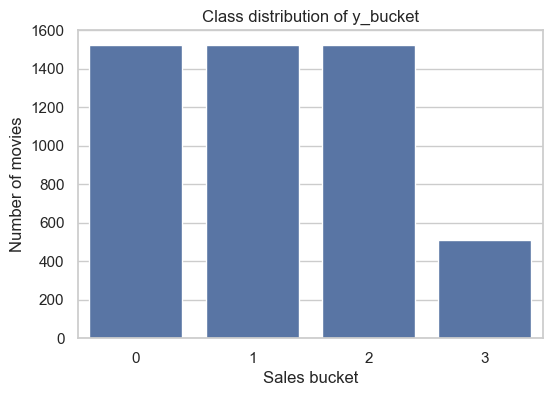

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
#Visual check of class balance

y = df_final_clean['y_bucket']

class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index() * 100

balance_df = pd.DataFrame({
    'count': class_counts,
    'percentage (%)': class_percent.round(2)
})


#Visual check of class balance
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class distribution of y_bucket")
plt.xlabel("Sales bucket")
plt.ylabel("Number of movies")
plt.show()


The class distribution of the target variable was inspected after bucketing worldwide box office revenue. Buckets 0, 1, 2 are approximately balanced, while the blockbuster bucket (bucket 3) is smaller by design. This reflects the natural skew of movie revenues and does not cause a severe class imbalance. Therefore, no resampling techniques were applied.
--> Use stratified splitting not K-folds, as we have more than 4000 row values
--> Use stratified splitting not other methods that handels imbalanced data, such as class weighting, smote or others

dont run the next following until the SVD is done


In [157]:
# Dataset splitting into Train, Validation, and Test sets------------------Ahmed

from sklearn.model_selection import train_test_split

X = X_final
y = df_final_clean['y_bucket'].values

# 1) 80% fitting, 20% testing
X_fit, X_test, y_fit, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2) From the 80% fitting: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_fit, y_fit,
    test_size=0.20,          # 20% of the fitting set
    random_state=42,
    stratify=y_fit
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# 3) datasets and objectives for modeling
train_set = (X_train, y_train)
val_set   = (X_val, y_val)
test_set  = (X_test, y_test)

# Verify class balance in each set
def balance(y_part):
    return pd.Series(y_part).value_counts(normalize=True).sort_index().round(3)

print("Train balance:\n", balance(y_train))
print("Val balance:\n", balance(y_val))
print("Test balance:\n", balance(y_test))

#check for NaNs in final datasets
print("NaNs in X_fit:", np.isnan(X_fit).sum())
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())

Train: (3251, 9)
Val: (813, 9)
Test: (1017, 9)
Train balance:
 0    0.3
1    0.3
2    0.3
3    0.1
Name: proportion, dtype: float64
Val balance:
 0    0.3
1    0.3
2    0.3
3    0.1
Name: proportion, dtype: float64
Test balance:
 0    0.3
1    0.3
2    0.3
3    0.1
Name: proportion, dtype: float64
NaNs in X_fit: 0
NaNs in X_train: 0
NaNs in X_val: 0


Now we start with AI models deployments, later evaluate their performance based on the same metric (F1). The objective of this phase is to build the best prediction model using the optimum model type

---

### 8. K-Nearest Neighbors (KNN) model and hyperparameter tuning

**Objective:**
To establish a distance-based baseline model for predicting movie sales buckets and evaluate its sensitivity to feature scaling and neighborhood size.

**Method:**
A K-Nearest Neighbors classifier was applied using standardized input features. Since KNN relies on distance calculations, all numeric features were scaled prior to model fitting. Model performance was evaluated using the macro-averaged F1 score to account for class distribution differences.

**Key design choices:**
- The number of neighbors (*k*) was varied to balance bias and variance.
- Multiple distance metrics (Euclidean, Manhattan, and Cosine) were tested to assess robustness.
- Both uniform and distance-based weighting schemes were evaluated.
- Hyperparameters were tuned using a validation set (or cross-validation on the fitting set).

**Outcome:**
The best-performing KNN configuration was selected based on validation performance and subsequently evaluated on the held-out test set to provide an unbiased estimate of model performance.


## Manual hyperparameter tuning

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import numpy as np

def fit_knn_model(X_train, y_train, k, metric, weights="uniform", p=2):
    """
    Fits scaler on train only, then KNN on scaled train.
    Returns: fitted knn, fitted scaler
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # p only matters for minkowski (p=1 manhattan, p=2 euclidean)
    if metric == "minkowski":
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights, p=p)
    else:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)

    knn.fit(X_train_scaled, y_train)
    return knn, scaler

## Hyperparameter grids
k_grid = list(range(1, 41))
metric_grid = ["minkowski", "cosine"]
weights_grid = ["uniform", "distance"]
p_grid = [1, 2]  # only for minkowski

best = {"score": -np.inf, "params": None}

for k in k_grid:
    for metric in metric_grid:
        for weights in weights_grid:
            if metric == "minkowski":
                for p in p_grid:
                    knn, scaler = fit_knn_model(X_train, y_train, k, metric, weights=weights, p=p)
                    y_pred = knn.predict(scaler.transform(X_val))
                    score = f1_score(y_val, y_pred, average="macro")

                    if score > best["score"]:
                        best = {"score": score, "params": {"k": k, "metric": metric, "weights": weights, "p": p}}
            else:
                knn, scaler = fit_knn_model(X_train, y_train, k, metric, weights=weights)
                y_pred = knn.predict(scaler.transform(X_val))
                score = f1_score(y_val, y_pred, average="macro")

                if score > best["score"]:
                    best = {"score": score, "params": {"k": k, "metric": metric, "weights": weights}}

print("Best validation macro-F1:", round(best["score"], 4))
print("Best params:", best["params"])

---

In [158]:

#Model No.1: KNN with Hyperparameter Tuning (k, metric, weights, p) ------------------Ahmed
# with GridSearchCV for hyperparameter tuning

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = [
    {
        "knn__n_neighbors": list(range(1, 41)),
        "knn__metric": ["minkowski"],
        "knn__weights": ["uniform", "distance"],
        "knn__p": [1, 2],
    },
    {
        "knn__n_neighbors": list(range(1, 41)),
        "knn__metric": ["cosine"],
        "knn__weights": ["uniform", "distance"],
        # no p for cosine
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,              # StratifiedKFold is used automatically for classification
    n_jobs=-1,
    refit=True
)

# IMPORTANT: Use fitting set only (train+val) for CV tuning
import numpy as np
X_fit = np.vstack([X_train, X_val])
y_fit = np.hstack([y_train, y_val])

grid.fit(X_fit, y_fit)

print("Best CV macro-F1:", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)


Best CV macro-F1: 0.666
Best params: {'knn__metric': 'cosine', 'knn__n_neighbors': 32, 'knn__weights': 'distance'}


#Model No.2: Random Forest model and hyperparameter tuning ------------------Ahmed


Objective:
To model nonlinear relationships between movie characteristics and sales categories while providing a robust ensemble-based benchmark that is less sensitive to feature scaling and outliers.

Method:
A Random Forest classifier was applied using an ensemble of decision trees trained on bootstrap samples of the data. Unlike distance-based models, Random Forest does not require feature scaling and can naturally handle mixed feature types. Model performance was evaluated using the macro-averaged F1 score to ensure balanced assessment across sales buckets.

Key design choices:

The number of trees (n_estimators) was varied to improve stability and reduce variance.

Maximum tree depth was tuned to control overfitting.

Minimum samples per split and per leaf were adjusted to improve generalization.

Feature subsampling strategies were explored to increase model diversity.

Class weighting was applied to account for the smaller blockbuster class.

Hyperparameters were tuned using cross-validation on the fitting set.

Outcome:
The best-performing Random Forest configuration was selected based on cross-validated performance and subsequently evaluated on the held-out test set to obtain an unbiased estimate of predictive performance.

Decision Tree – Validation macro F1: 0.6241
Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 400}
Best RF CV macro F1: 0.6963
Random Forest – Validation macro F1: 0.6997
Random Forest – TEST macro F1: 0.6939
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       305
           1       0.62      0.55      0.58       305
           2       0.67      0.76      0.71       305
           3       0.71      0.68      0.69       102

    accuracy                           0.70      1017
   macro avg       0.70      0.69      0.69      1017
weighted avg       0.69      0.70      0.69      1017



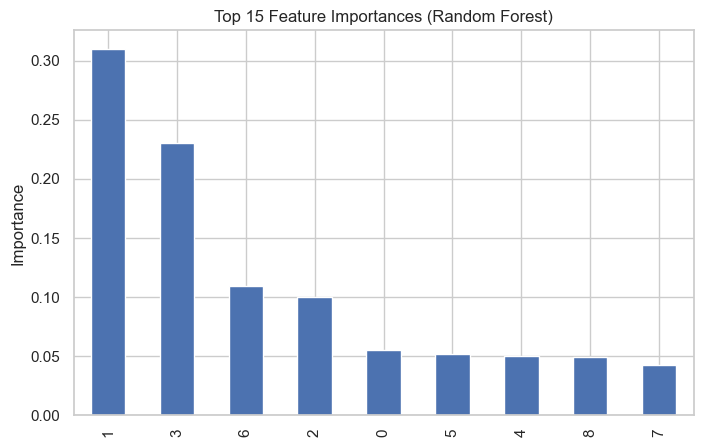

In [159]:
#1. Decision Tree (baseline tree model) ------------------Ahmed

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # safe choice given blockbuster class
)

dt.fit(X_train, y_train)

y_val_pred = dt.predict(X_val)
print("Decision Tree – Validation macro F1:",
      round(f1_score(y_val, y_val_pred, average='macro'), 4))

#2. Random Forest model and hyperparameter tuning (main tree model)   ------------------Ahmed
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
#3. Grid search (on fitting set only)------------------Ahmed
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV macro F1:", round(rf_grid.best_score_, 4))

#4. Evaluate best RF on validation set for hyperparameter tuning ------------------Ahmed
rf_best = rf_grid.best_estimator_

y_val_pred = rf_best.predict(X_val)
print("Random Forest – Validation macro F1:",
      round(f1_score(y_val, y_val_pred, average='macro'), 4))

#5. Evaluate model performance of best RF on test set ------------------Ahmed
y_test_pred = rf_best.predict(X_test)

print("Random Forest – TEST macro F1:",
      round(f1_score(y_test, y_test_pred, average='macro'), 4))
print(classification_report(y_test, y_test_pred))

#6. Feature importance visualization for best RF model ------------------Ahmed
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_best.feature_importances_
feat_importance = pd.Series(importances).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_importance.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.show()

Tree-based models were applied to capture nonlinear relationships between features and movie sales categories. A Decision Tree was used as an interpretable baseline, followed by a Random Forest classifier to improve generalization. Random Forest hyperparameters were tuned using cross-validation on the training set and evaluated using the macro-averaged F1 score. Class weighting was applied to account for the smaller blockbuster class.

Benefits of random forest model to the project scope
- No scaling needed
- Works with structured + SVD features
- Robust to remaining outliers
- Handles mixed feature types
- Strong comparison vs KNN & ANN


---

# 9. Artificial Neural Network (ANN) for Multi-Class Text Classification

## Objective
This section implements an **Artificial Neural Network (ANN)**, operationalised as a **Multilayer Perceptron (MLP)**, to predict the target variable **`y_bucket`** (multi-class classification). The ANN complements earlier baseline and tree-based models by introducing a **non-linear, gradient-based learner** that can model complex decision boundaries in high-dimensional feature spaces.

## Context in the pipeline
The ANN is trained on the final feature representation **`X_final`** that has already been created in the earlier pipeline (e.g., engineered features and/or reduced-dimensional representations such as SVD-based components). Therefore, the ANN does **not** replace the feature engineering stage; it operates as a downstream predictive model.

## Why an ANN is relevant here
An ANN is appropriate when:
1. **Non-linear relationships** are expected between features and the target.
2. Feature vectors are **dense and numeric**, which is typical after embedding and dimensionality reduction.
3. A flexible function approximator is required to potentially exceed the performance of linear baselines.

In addition, the assignment requires that a neural network is implemented and that **training and validation loss curves** are plotted to determine a suitable number of epochs.

---

In [160]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

## Step 1 — Data Preparation for Neural Network Training

In this step, input features are standardised using feature scaling, and data types are aligned with neural network requirements. Feature scaling is applied based on training-set statistics to ensure numerical stability during optimisation, and the same transformation is reused for validation and test data to prevent data leakage. Target labels are converted to integer class indices, as required for multi-class classification loss functions.

This preparation step is essential for stable gradient-based learning and ensures compatibility with the neural network training framework.


In [161]:
# Scaling (fit on train only)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Ensure correct dtypes
X_train_s = X_train_s.astype(np.float32)
X_val_s   = X_val_s.astype(np.float32)
X_test_s  = X_test_s.astype(np.float32)

# Ensure labels are integer class indices
y_train_i = y_train.astype(np.int64)
y_val_i   = y_val.astype(np.int64)
y_test_i  = y_test.astype(np.int64)

n_features = X_train_s.shape[1]
n_classes  = len(np.unique(y_train_i))

print("ANN input features:", n_features)
print("ANN classes:", n_classes)

ANN input features: 9
ANN classes: 4


## Step 2 — Mini-Batch Data Preparation

The scaled feature matrices and target labels are converted into tensor-based datasets and loaded using mini-batch iterators. This enables efficient batch-wise training and optional shuffling of the training data.

Mini-batch learning improves computational efficiency, stabilises gradient updates, and supports scalable neural network training.


In [162]:
# Torch datasets/loaders

def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## Step 3 — Neural Network Architecture

A Multilayer Perceptron (MLP) is defined with fully connected layers, ReLU activations, and dropout regularisation. The network maps input features to class-level outputs through non-linear transformations, producing logits for multi-class classification.

This architecture enables the model to capture complex, non-linear relationships while mitigating overfitting.

In [163]:
# Model definition (MLP)

class MLP(nn.Module):
    def __init__(self, n_in, n_out, hidden_sizes=(256, 128), dropout=0.3):
        super().__init__()
        layers = []
        prev = n_in
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Step 4 — Define the learning objective (loss) and optimisation strategy

### What this step does
This step specifies:
- the **loss function**: `CrossEntropyLoss` for multi-class classification
- the **optimiser**: Adam
- optional **L2 regularisation** via `weight_decay`

### How it works
**Cross-Entropy Loss** compares predicted class distributions with true labels. For a single sample with true class \( y \) and predicted probabilities \( p_k \):
\[
\mathcal{L} = -\log(p_y)
\]

Adam is an adaptive gradient method that maintains moving averages of:
- gradients (first moment)
- squared gradients (second moment)  
This typically leads to faster and more stable convergence than plain SGD.

`weight_decay` adds an L2 penalty to large weights, discouraging overly complex solutions.

### Why this step is necessary
- A classification model requires a principled objective; cross-entropy is standard for multi-class targets.
- Adam generally converges reliably with minimal tuning, making it appropriate for this project.
- Weight decay and dropout reduce overfitting and improve generalisation.


In [164]:
# Train/eval utilities

def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            y_true.append(yb.detach().cpu().numpy())
            y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, macro_f1

def train_ann(
    hidden_sizes=(256,128),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=64,
    max_epochs=50,
    patience=7,
    device=None
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader = make_loader(X_train_s, y_train_i, batch_size=batch_size, shuffle=True)
    val_loader   = make_loader(X_val_s, y_val_i, batch_size=batch_size, shuffle=False)

    model = MLP(n_features, n_classes, hidden_sizes=hidden_sizes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_f1 = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        va_loss, va_f1 = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_f1s.append(tr_f1)
        val_f1s.append(va_f1)

        print(f"Epoch {epoch:02d} | Train loss {tr_loss:.4f} F1 {tr_f1:.4f} | Val loss {va_loss:.4f} F1 {va_f1:.4f}")

        # Early stopping on val loss
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_f1": train_f1s,
        "val_f1": val_f1s,
        "best_val_loss": best_val_loss
    }
    return model, history

## Step 7 — Hyperparameter Selection and Training Diagnostics

A controlled search over key hyperparameters is conducted, and configurations are evaluated using validation performance. The best model is selected based on validation metrics obtained during training with early stopping.

Training and validation loss curves are analysed to assess convergence behaviour and detect overfitting. These diagnostics support informed hyperparameter selection and validate the chosen training duration.


In [165]:
# Minimal hyperparameter search

param_grid = [
    {"hidden_sizes": (128,),      "dropout": 0.2, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 64},
    {"hidden_sizes": (256,128),   "dropout": 0.3, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 64},
    {"hidden_sizes": (256,128),   "dropout": 0.4, "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 64},
]

best = {"val_f1": -1, "model": None, "history": None, "params": None}

for p in param_grid:
    print("\nTesting params:", p)
    model, hist = train_ann(
        hidden_sizes=p["hidden_sizes"],
        dropout=p["dropout"],
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        batch_size=p["batch_size"],
        max_epochs=60,
        patience=20
    )

    # Choose best by max validation macro-F1 (last epoch in history after early stop)
    val_f1 = max(hist["val_f1"])
    if val_f1 > best["val_f1"]:
        best.update({"val_f1": val_f1, "model": model, "history": hist, "params": p})

print("\nBest ANN params:", best["params"])
print("Best ANN Val macro-F1:", best["val_f1"])


Testing params: {'hidden_sizes': (128,), 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64}
Epoch 01 | Train loss 1.1707 F1 0.4549 | Val loss 0.9877 F1 0.5091
Epoch 02 | Train loss 0.9073 F1 0.5736 | Val loss 0.8518 F1 0.5768
Epoch 03 | Train loss 0.8196 F1 0.6271 | Val loss 0.7968 F1 0.6107
Epoch 04 | Train loss 0.7831 F1 0.6341 | Val loss 0.7663 F1 0.6441
Epoch 05 | Train loss 0.7563 F1 0.6630 | Val loss 0.7479 F1 0.6332
Epoch 06 | Train loss 0.7425 F1 0.6556 | Val loss 0.7360 F1 0.6496
Epoch 07 | Train loss 0.7330 F1 0.6708 | Val loss 0.7236 F1 0.6520
Epoch 08 | Train loss 0.7298 F1 0.6824 | Val loss 0.7191 F1 0.6569
Epoch 09 | Train loss 0.7164 F1 0.6782 | Val loss 0.7154 F1 0.6673
Epoch 10 | Train loss 0.7195 F1 0.6827 | Val loss 0.7075 F1 0.6642
Epoch 11 | Train loss 0.7220 F1 0.6831 | Val loss 0.7026 F1 0.6725
Epoch 12 | Train loss 0.7106 F1 0.6844 | Val loss 0.7001 F1 0.6759
Epoch 13 | Train loss 0.7084 F1 0.6840 | Val loss 0.6975 F1 0.6768
Epoch 14 | Train

Epoch 18 | Train loss 0.6966 F1 0.6964 | Val loss 0.6869 F1 0.6824
Epoch 19 | Train loss 0.6954 F1 0.6959 | Val loss 0.6855 F1 0.6737
Epoch 20 | Train loss 0.6940 F1 0.6875 | Val loss 0.6843 F1 0.6782
Epoch 21 | Train loss 0.6958 F1 0.7000 | Val loss 0.6842 F1 0.6764
Epoch 22 | Train loss 0.6934 F1 0.6951 | Val loss 0.6850 F1 0.6764
Epoch 23 | Train loss 0.6926 F1 0.6964 | Val loss 0.6831 F1 0.6758
Epoch 24 | Train loss 0.6897 F1 0.7030 | Val loss 0.6828 F1 0.6812
Epoch 25 | Train loss 0.6854 F1 0.7005 | Val loss 0.6813 F1 0.6883
Epoch 26 | Train loss 0.6886 F1 0.6978 | Val loss 0.6790 F1 0.6832
Epoch 27 | Train loss 0.6868 F1 0.6896 | Val loss 0.6808 F1 0.6804
Epoch 28 | Train loss 0.6821 F1 0.7005 | Val loss 0.6804 F1 0.6767
Epoch 29 | Train loss 0.6847 F1 0.6977 | Val loss 0.6785 F1 0.6779
Epoch 30 | Train loss 0.6822 F1 0.7034 | Val loss 0.6765 F1 0.6824
Epoch 31 | Train loss 0.6825 F1 0.7070 | Val loss 0.6769 F1 0.6799
Epoch 32 | Train loss 0.6837 F1 0.7022 | Val loss 0.6766 F1 0.

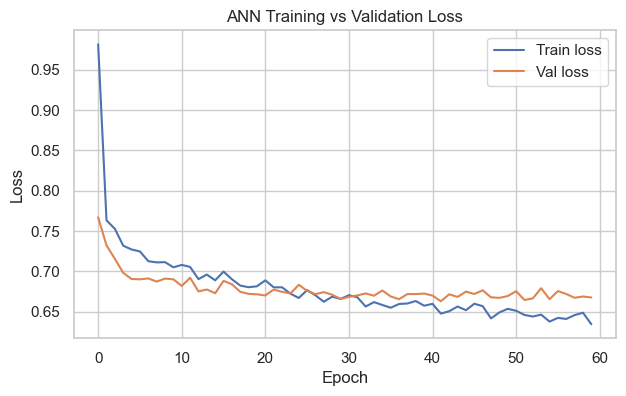

In [166]:
# Plot loss curves

plt.figure(figsize=(7,4))
plt.plot(best["history"]["train_loss"], label="Train loss")
plt.plot(best["history"]["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.show()

In [167]:
# Test set evaluation

device = "cuda" if torch.cuda.is_available() else "cpu"
best_model = best["model"].to(device)
test_loader = make_loader(X_test_s, y_test_i, batch_size=128, shuffle=False)

criterion = nn.CrossEntropyLoss()
test_loss, test_f1 = run_epoch(best_model, test_loader, criterion, optimizer=None, device=device)

# Get detailed predictions
best_model.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = best_model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.append(preds)
        all_true.append(yb.numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print("\nANN Test loss:", round(test_loss, 4))
print("ANN Test macro-F1:", round(test_f1, 4))
print("\nClassification report:\n", classification_report(all_true, all_pred))

print("\nConfusion matrix:\n", confusion_matrix(all_true, all_pred))


ANN Test loss: 0.7148
ANN Test macro-F1: 0.6985

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       305
           1       0.62      0.55      0.58       305
           2       0.70      0.74      0.72       305
           3       0.74      0.68      0.71       102

    accuracy                           0.70      1017
   macro avg       0.70      0.70      0.70      1017
weighted avg       0.70      0.70      0.70      1017


Confusion matrix:
 [[251  49   4   1]
 [ 77 167  61   0]
 [  7  50 225  23]
 [  0   2  31  69]]


In [168]:
# --------------------------------------------------
# TEMPORARY TARGET FOR BONUS ANALYSIS ONLY
# Robust quartile bucketing (handles duplicates)
# --------------------------------------------------

# Drop missing or zero values for bucketing
valid_mask = df_master['worldwide_box_office'] > 0

# Create quantile buckets WITHOUT labels first
y_bins = pd.qcut(
    df_master.loc[valid_mask, 'worldwide_box_office'],
    q=4,
    duplicates='drop'
)

# Convert bins to integer codes (0, 1, 2, ...)
df_master.loc[valid_mask, 'y_bucket'] = y_bins.cat.codes

# Fill missing (zero box office) as lowest bucket
df_master['y_bucket'] = df_master['y_bucket'].fillna(0).astype(int)

print("y_bucket distribution (df_master):")
print(df_master['y_bucket'].value_counts().sort_index())


y_bucket distribution (df_master):
y_bucket
0    4215
1    1270
2    1270
3    1270
Name: count, dtype: int64


# Explainability


In [170]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   --------------------------------------- 549.1/549.1 kB 11.8 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [171]:
#Preparing Shap (Global/Local)-----------------------------------------------------------------------------Ahmed
#Global: which features matter overall?
#Local: why did the model predict bucket X for one movie?


import shap

#A) Preparing data for SHAP--------------------------------------------------------------------------------Ahmed
# Only run this if your X_train, X_val, X_test are numpy arrays
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_val_df   = pd.DataFrame(X_val, columns=feature_names)
X_test_df  = pd.DataFrame(X_test, columns=feature_names)

#B) sample run for SHAP--------------------------------------------------------------------------------Ahmed
# Use a smaller background sample for speed (SHAP best practice) for ANN
X_bg = X_train_df.sample(n=min(200, len(X_train_df)), random_state=42)
X_explain = X_test_df.sample(n=min(300, len(X_test_df)), random_state=42)

print("Background shape:", X_bg.shape)
print("Explain shape:", X_explain.shape)

#C) SHAP for ANNN--using KernelExplainer (model-agnostic, slower)--------------------------------------------Ahmed
#KernelExplainer needs a prediction function that returns probabilities.

# prediction function for KernelSHAP (must return probabilities)
def predict_proba_fn(X_array):
    X_df_tmp = pd.DataFrame(X_array, columns=feature_names)
    return best_model.predict_proba(X_df_tmp)

explainer = shap.KernelExplainer(predict_proba_fn, X_bg)

# Compute SHAP values (multiclass => list of arrays, one per class)
shap_values = explainer.shap_values(X_exp, nsamples=200)

#D) Global SHAP plots (Deliverable: SHAP plots + interpretation)--------------------------------------------Ahmed
#Preparing Shap (Global)-----------------------------------------------------------------------------Ahmed
#Global: which features matter overall?


#1) Global summary plot (beeswarm)
# Find index of class "3" in your model classes (blockbuster class)
# shows which features drive predictions overall and whether they push toward higher/lower bucket probability.

#We choose here which class to explain:
#For blockbusters ------ explain bucket 3
#Otherwise use another class index of interest
classes = best_model.classes_
class_idx = list(classes).index(3) if 3 in classes else 0

shap.summary_plot(
    shap_values[class_idx],
    X_exp,
    feature_names=feature_names,
    show=True
)


#2) Global importance bar plot (mean |SHAP|)
# theclearest “top features” plot for reports.

shap.summary_plot(
    shap_values[class_idx],
    X_exp,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

#E) Local SHAP explanation for 1 movie (Deliverable: SHAP plot + interpretation)
#for a sample movie from test set (one instance) — ideally the same one you will use for counterfactuals. ------------------Ahmed --- use same as in SHAP local explanation if possible
query_instance = X_test_df.iloc[[0]]  # keep DataFrame shape
i = 0
x_one = X_exp.iloc[i:i+1]

pred_class = int(best_model.predict(x_one)[0])
proba = best_model.predict_proba(x_one)[0]

print("Predicted class:", pred_class)
print("Class probabilities:", dict(zip(classes, np.round(proba, 3))))

#Local force plot (good quick local visualization)
shap.force_plot(
    explainer.expected_value[class_idx],
    shap_values[class_idx][i],
    x_one.iloc[0],
    matplotlib=True
)
#F) show the TOP contributing features clearly giving a (((top drivers))) printout for interpretation (very useful in the report)
# Top contributing features (absolute impact) for the predicted class
sv = pd.Series(shap_values[class_idx_pred][i], index=feature_names)
top = sv.abs().sort_values(ascending=False).head(8)

print("\nTop SHAP drivers for predicted class:", pred_class)
display(pd.DataFrame({
    "feature": top.index,
    "shap_value": sv[top.index].values
}))

NameError: name 'feature_names' is not defined

### SHAP Interpretation (Best model)

**Global explanation:**
The SHAP summary plot shows which predictors contribute most to sales-bucket predictions across the dataset. Features with higher mean absolute SHAP values have the strongest influence on the model’s decisions.

**Local explanation (example movie):**
For the selected movie instance, SHAP values indicate which variables increased the probability of the predicted class and which reduced it. This provides a transparent “why” behind the model output before generating counterfactual actions.


In [172]:
#Preparing Counterfactual Explainability (DiCE)---------------------------------------------------------Ahmed

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
#import dice_ml
import sys
!"{sys.executable}" -m pip install -U pip
!"{sys.executable}" -m pip install dice-ml



from sklearn.metrics import pairwise_distances


#1) Define feature names exactly matching X_structured (used for modeling)-----------------Ahmed
feature_names = [
    'runtime_scaled',
    'log_budget_scaled',
    'budget_missing',
    'user_review_count',
    'user_positive_ratio',
    'user_sentiment_mean',
    'expert_review_count',
    'expert_positive_ratio',
    'expert_sentiment_mean'
]

#2) Split final data into DataFrames for DiCE compatibility-----------------Ahmed
X_df = pd.DataFrame(X_final, columns=feature_names)
y_df = pd.Series(df_final_clean['y_bucket'].values, name='y_bucket')

print("X_df shape:", X_df.shape)
print("Total NaNs in X_df:", int(X_df.isna().sum().sum()))




X_fit_df, X_test_df, y_fit, y_test = train_test_split(
    X_df, y_df,
    test_size=0.20,
    random_state=42,
    stratify=y_df
)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_fit_df, y_fit,
    test_size=0.20,
    random_state=42,
    stratify=y_fit
)

print("Train:", X_train_df.shape, "Val:", X_val_df.shape, "Test:", X_test_df.shape)
#3) Choose your best model type
best_model_type = "ANN"   # "knn" OR "ann" OR "rf"


#4) in case best performing model is ANN ------   (sklearn MLP) if another  -----Ahmed
#If ANN is PyTorch, DiCE may not plug in cleanly via sklearn backend. In that case (PyTorch or Keras), counterfactual tool block needs to be adjusted (usually alibi for TF/PyTorch)



def build_ann():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=400,
            random_state=42
        ))
    ])



#5) Fit best model on full train+val set for counterfactuals (explainability)------------------Ahmed
X_trainval = pd.concat([X_train_df, X_val_df], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

if best_model_type == "knn":
    best_model = build_knn()
elif best_model_type == "ann":
    best_model = build_ann()
else:
    best_model = build_rf()

best_model.fit(X_trainval, y_trainval)
print("Model fitted:", best_model_type)




#6)Create DiCE objects to generate counterfactual explanations------------------Ahmed

dice_data_df = X_trainval.copy()
dice_data_df["y_bucket"] = y_trainval.values

continuous_features = [
    'runtime_scaled',
    'log_budget_scaled',
    'user_review_count',
    'user_positive_ratio',
    'user_sentiment_mean',
    'expert_review_count',
    'expert_positive_ratio',
    'expert_sentiment_mean'
]
# budget_missing is binary -> not continuous

dice_data = dice_ml.Data(
    dataframe=dice_data_df,
    continuous_features=continuous_features,
    outcome_name="y_bucket"
)

dice_model = dice_ml.Model(model=best_model, backend="sklearn")
exp = dice_ml.Dice(dice_data, dice_model, method="random")


#7) Generate counterfactuals for a sample movie from test set------------------Ahmed     ------ use same as in SHAP local explanation if possible
query_instance = X_test_df.iloc[[0]]  # keep DataFrame shape
true_class = int(y_test.iloc[0])
pred_class = int(best_model.predict(query_instance)[0])

print("True:", true_class, "| Pred:", pred_class)


#8) Generate counterfactuals (target: blockbuster bucket = 3)-------------------------Ahmed
features_to_vary = [
    "runtime_scaled",
    "log_budget_scaled",
    "user_sentiment_mean",
    "expert_sentiment_mean",
    "user_positive_ratio",
    "expert_positive_ratio"
]

cf = exp.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class=3,
    features_to_vary=features_to_vary
)

cf.visualize_as_dataframe(show_only_changes=True)


#9) Analyze visuals of the counterfactuals------------------Ahmed

#Visual 1 — Before vs After: Predicted probabilities (best visual) shows (model belief shift) -------------------------Ahmed
# Original instance
x0 = query_instance.copy()

# Get DiCE counterfactuals as dataframe (first set)
cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

# Make sure we only use feature columns (drop outcome if it exists)
cf_features = [c for c in x0.columns]
cf_df = cf_df[cf_features]

# Predict probabilities
proba_before = best_model.predict_proba(x0)[0]
proba_after  = best_model.predict_proba(cf_df)

classes = best_model.classes_

# Plot: probability distribution before
plt.figure(figsize=(7,4))
plt.bar(classes, proba_before)
plt.title("Prediction probabilities (Original instance)")
plt.xlabel("Class (y_bucket)")
plt.ylabel("Probability")
plt.show()

# Plot: probability distribution after (first counterfactual)
plt.figure(figsize=(7,4))
plt.bar(classes, proba_after[0])
plt.title("Prediction probabilities (Counterfactual #1)")
plt.xlabel("Class (y_bucket)")
plt.ylabel("Probability")
plt.show()


#Visual 2 — What changed? (Feature delta bar chart) Shows exactly which features DiCE altered -------------------------Ahmed
# Choose which CF to visualize
cf1 = cf_df.iloc[0]
x0_row = x0.iloc[0]

delta = (cf1 - x0_row)

# only show changed features
delta_changed = delta[delta != 0].sort_values(key=lambda s: np.abs(s), ascending=False)

plt.figure(figsize=(8,4))
plt.bar(delta_changed.index, delta_changed.values)
plt.title("Feature changes (Counterfactual #1 minus Original)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Change amount")
plt.tight_layout()
plt.show()


#Visual 3 — Heatmap of changes across multiple counterfactuals very explainable and looks easily interpretable---------------Ahmed
# Compute deltas for all CFs
delta_all = cf_df.copy()
for col in cf_features:
    delta_all[col] = delta_all[col] - x0_row[col]

# Keep only columns that changed in at least one CF
changed_cols = delta_all.columns[(delta_all != 0).any(axis=0)]
delta_all = delta_all[changed_cols]

plt.figure(figsize=(10,4))
sns.heatmap(delta_all, annot=False, center=0)
plt.title("Counterfactual feature changes (all CFs)")
plt.xlabel("Features changed")
plt.ylabel("Counterfactual index")
plt.tight_layout()
plt.show()


#Visual 4 — How “far” are the counterfactuals? (distance plot)-------------------------Ahmed
# Shows which CF is closest to original (useful for interpretation).

# Distance between original and each CF (Euclidean)
dists = pairwise_distances(cf_df.values, x0.values, metric="euclidean").flatten()

plt.figure(figsize=(7,4))
plt.bar(range(1, len(dists)+1), dists)
plt.title("Distance from original to each counterfactual")
plt.xlabel("Counterfactual #")
plt.ylabel("Euclidean distance")
plt.show()

print("Closest CF index:", int(dists.argmin()) + 1, "| distance:", float(dists.min()))


#Visual 5 — Global explanation (if best model is Random Forest)-------------------------Ahmed

#A) Built-in feature importances (nice & simple)-------------------------Ahmed

if best_model_type == "rf":
    rf = best_model.named_steps["model"]
    imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    imp.head(10).plot(kind="bar")
    plt.title("Top 10 Feature Importances (Random Forest)")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

#B) Permutation importances (more robust/model-agnostic)-------------------------Ahmed
perm = permutation_importance(
    best_model, X_test_df, y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42
)

perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,4))
perm_imp.head(10).plot(kind="bar")
plt.title("Top 10 Permutation Importances (macro F1 impact)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()




   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 29.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1
    Uninstalling pip-25.1:
      Successfully uninstalled pip-25.1

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 27.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 36.9 MB/s  0:00:00
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------- ----------------------------- 18.1/72.0 MB 85.5 MB/s eta 0:00:01
   -------------------- ------------------- 36.2/72.0 MB 84.1 MB/s eta 0:00:01
   ------------------------------- -------- 56.1/72.0 MB 85.5 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 85.8 MB/s eta 0:00:01
   ---------------------------------------  

NameError: name 'build_rf' is not defined

In [ ]:
# Comparison SHAP drivers vs counterfactual changes ------------------ Ahmed

# Take first counterfactual only
cf1 = cf_df.iloc[0]
delta1 = (cf1 - query_instance.iloc[0])

compare = shap_contrib.copy()
compare["cf_change"] = compare["feature"].map(delta1.to_dict())
compare["abs_shap"] = compare["shap_value"].abs()

# Show features that are BOTH important and changed
compare = compare.sort_values(["abs_shap"], ascending=False)

display(compare.head(12))


In [ ]:
# ==================================================
# BONUS 9 — Topic Discovery using Transformer Embeddings
# ==================================================

"""
Objective:
Identify latent semantic topics in expert movie reviews using transformer-based
embeddings and assess whether these topics are associated with box office success.

Method:
- Use SVD-reduced DistilBERT embeddings of expert reviews
- Apply KMeans clustering to discover latent semantic topics
- Interpret topics using representative movies and metadata
- Analyze topic distributions across box office success buckets
"""

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


### Selecting Transformer-Based Semantic Features

This step selects the transformer-derived semantic features used for topic discovery. Only the SVD-reduced expert review embeddings are included, ensuring that clustering is driven purely by review meaning rather than financial or production-related variables.


In [ ]:
# --------------------------------------------------
# 1. SELECT TRANSFORMER-BASED FEATURES
# --------------------------------------------------
# Only semantic features are used for topic discovery
embedding_cols = [c for c in df_master.columns if c.startswith("expert_svd_")]
X_embeddings = df_master[embedding_cols].values

print("Embedding matrix shape:", X_embeddings.shape)

Embedding matrix shape: (8025, 50)


### Feature Selection Summary

The resulting embedding matrix contains one semantic representation per movie, with 50 dimensions capturing the most informative latent review features. This compact representation preserves the semantic structure of expert reviews while remaining efficient for clustering.


### Topic Discovery via Transformer-Based Clustering

This section applies a transformer-based clustering approach to identify the main semantic topics present in expert movie reviews. By grouping reviews with similar meaning, we uncover recurring review themes and examine whether these themes are associated with different levels of box office success.


In [ ]:
# --------------------------------------------------
# 2. TOPIC DISCOVERY VIA KMEANS
# --------------------------------------------------
# Each cluster approximates a latent semantic theme in expert reviews

N_TOPICS = 10

topic_model = KMeans(
    n_clusters=N_TOPICS,
    random_state=42,
    n_init=10
)

df_master["review_topic"] = topic_model.fit_predict(X_embeddings)

print("Topic distribution:")
print(df_master["review_topic"].value_counts().sort_index())

Topic distribution:
review_topic
0     529
1     984
2     569
3    1271
4     926
5     270
6     847
7     789
8    1033
9     807
Name: count, dtype: int64


### Interpretation of Results

The clustering reveals distinct and meaningful review topics that differ in their association with box office performance. Topics related to action-driven, mainstream, and franchise-style movies appear more frequently among high-performing and blockbuster films, while topics dominated by documentaries, prestige dramas, or niche narratives are more common in lower revenue categories. These findings suggest that the semantic content of expert reviews provides useful signals for predicting commercial success.


### Interpreting Topics Using Representative Movies

Since the original review text is not retained after transformer embedding, each discovered topic is interpreted by examining representative movies within the cluster. Movie titles, genres, summaries, and average expert sentiment are used as semantic proxies to understand the dominant theme of each topic.


In [ ]:
# --------------------------------------------------
# 3. INTERPRET TOPICS VIA REPRESENTATIVE MOVIES
# --------------------------------------------------
# Raw review text is not retained after embedding, therefore
# topics are interpreted via movie-level semantic proxies.

topic_labels = {
    0: "Documentary & Biography (Niche / Critical)",
    1: "Action-Driven Franchises & Crime Thrillers",
    2: "Historical & Socially Conscious Drama",
    3: "High-Tension Thrillers & Survival",
    4: "Comedy & Light Entertainment",
    5: "Crime / Mystery / Psychological Drama",
    6: "Mixed-Genre Mid-Budget Drama",
    7: "Prestige Drama (Awards-Oriented)",
    8: "Romance & Relationship Stories",
    9: "Genre Hybrids & Experimental Narratives"
}

for topic in range(N_TOPICS):
    print("\n" + "=" * 60)
    print(f"Topic {topic}: {topic_labels[topic]}")
    print("=" * 60)

    display(
        df_master[df_master["review_topic"] == topic]
        [["title", "genre", "summary", "expert_sentiment_mean"]]
        .head(5)
    )


Topic 0: Documentary & Biography (Niche / Critical)


,title,genre,summary,expert_sentiment_mean
30,20 Feet from Stardom,Documentary,Backup singers live in a world that lies just ...,0.773831
31,"20,000 Days on Earth","Drama,Music,Documentary",Drama and reality combine in a fictitious 24 h...,0.670217
40,21 Years: Richard Linklater,"Biography,Documentary",No summary available,0.164905
72,40 Years in the Making: The Magic Music Movie,Documentary,TV writer/producer Lee Aronsohn tracks down th...,0.990584
73,42,"Biography,Drama,Sport",The life story of Jackie Robinson and his hist...,0.425544



Topic 1: Action-Driven Franchises & Crime Thrillers


,title,genre,summary,expert_sentiment_mean
2,100 Bloody Acres,"Horror,Comedy",Reg and Lindsay run an organic fertilizer busi...,0.789073
10,12 Rounds,"Action,Thriller,Crime",No summary available,-0.221159
22,16 Blocks,"Action,Drama,Thriller,Crime",The story of how two men change -- and change ...,0.281074
28,2 Fast 2 Furious,"Action,Thriller,Crime",Former cop Brian O'Conner (Paul Walker) teams ...,-0.332470
29,2 Guns,"Action,Drama,Thriller,Comedy,Crime",A DEA agent and an undercover Naval Intelligen...,-0.026793



Topic 2: Historical & Socially Conscious Drama


...

,title,genre,summary,expert_sentiment_mean
25,1945,Drama,No summary available,0.834041
26,1985,Drama,No summary available,0.599469
34,20th Century Women,"Drama,Comedy",No summary available,0.703285
38,21 Grams,"Drama,Thriller,Crime",They say we all lose 21 grams at the exact mom...,0.222774
52,3,"Drama,Comedy,Romance",No summary available,0.003439



Topic 8: Romance & Relationship Stories


,title,genre,summary,expert_sentiment_mean
1,10 Years,"Drama,Comedy,Romance",No summary available,0.335933
8,12 Hour Shift,"Thriller,Horror,Comedy",No summary available,0.683174
43,23 Blast,"Drama,Sport,Family",When high school football star Travis Freeman ...,0.199156
48,27 Dresses,"Comedy,Romance",No summary available,-0.040576
84,5 Flights Up,Drama,No summary available,0.195657



Topic 9: Genre Hybrids & Experimental Narratives


,title,genre,summary,expert_sentiment_mean
3,"10,000 km","Drama,Comedy,Romance","Two people in love, two apartments - one in Ba...",0.351547
4,1001 Grams,Drama,When Norwegian scientist Marie attends a semin...,0.715748
7,12,"Drama,Thriller,Crime,War",No summary available,0.491305
17,13 Sins,"Thriller,Horror","A bright but meek salesman, drowning in debt a...",-0.441273
44,24 City,Drama,No summary available,0.454831


### Topic Interpretation Summary

The representative movies within each cluster reveal coherent and interpretable themes, such as documentaries and biographies, action-driven franchises, prestige dramas, and light entertainment. This confirms that the transformer-based embeddings successfully capture meaningful semantic differences in expert reviews. The manually assigned topic labels provide an interpretable bridge between unsupervised clustering results and real-world movie characteristics.


### Topics vs Box Office Success

This section examines whether the semantic topics identified from expert reviews are associated with different levels of box office performance. By comparing topic membership with box office success buckets, we assess whether certain review themes tend to correspond to commercially successful movies.


In [ ]:
# --------------------------------------------------
# 4. TOPICS VS BOX OFFICE SUCCESS
# --------------------------------------------------
# Evaluate whether certain semantic topics are associated
# with different box office performance tiers

topic_success_table = (
    df_master
    .groupby(["review_topic", "y_bucket"])
    .size()
    .unstack(fill_value=0)
)

# Normalize row-wise for interpretability
topic_success_pct = topic_success_table.div(
    topic_success_table.sum(axis=1), axis=0
)

# Add human-readable topic labels to index (for visualization)
topic_success_pct.index = topic_success_pct.index.map(
    lambda x: f"{x}: {topic_labels[x]}"
)


### Interpretation of Topic–Success Relationship

The results show that review topics are not evenly distributed across box office success tiers. Some topics appear more frequently among high-performing and blockbuster movies, while others are concentrated in lower revenue categories. This indicates that the semantic themes present in expert reviews capture meaningful differences related to commercial performance and can serve as informative predictors of movie success.


### Visualization: Review Topics vs Box Office Success

The following heatmap visualizes the relationship between discovered review topics and box office success buckets. Values are row-normalized, showing the proportion of movies within each topic that fall into each performance tier.


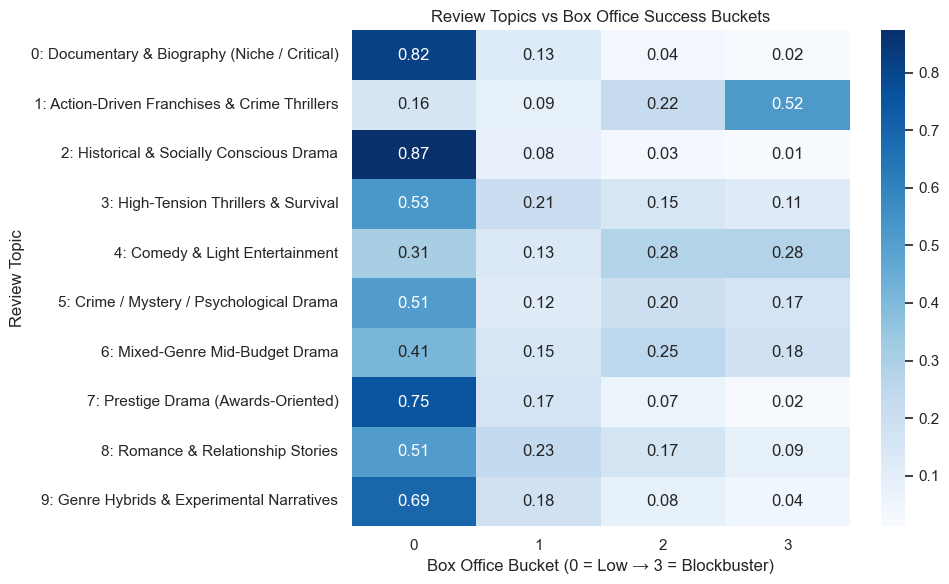

In [ ]:
# --------------------------------------------------
# 5. VISUALIZATION: TOPIC → SUCCESS RELATIONSHIP
# --------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(
    topic_success_pct,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Review Topics vs Box Office Success Buckets")
plt.xlabel("Box Office Bucket (0 = Low → 3 = Blockbuster)")
plt.ylabel("Review Topic")
plt.tight_layout()
plt.show()

### Heatmap Interpretation

The heatmap highlights clear differences across topics. Action-driven and mainstream entertainment topics show a higher concentration in the blockbuster bucket, while documentary, historical, and niche drama topics are predominantly associated with lower box office performance. This visual evidence reinforces that semantic review topics are meaningfully linked to commercial outcomes.


### Optional: PCA Visualization of Review Topics

This section provides a diagnostic visualization of the discovered review topics using Principal Component Analysis (PCA). The high-dimensional transformer embeddings are projected into two dimensions to visually inspect topic separation and overlap.


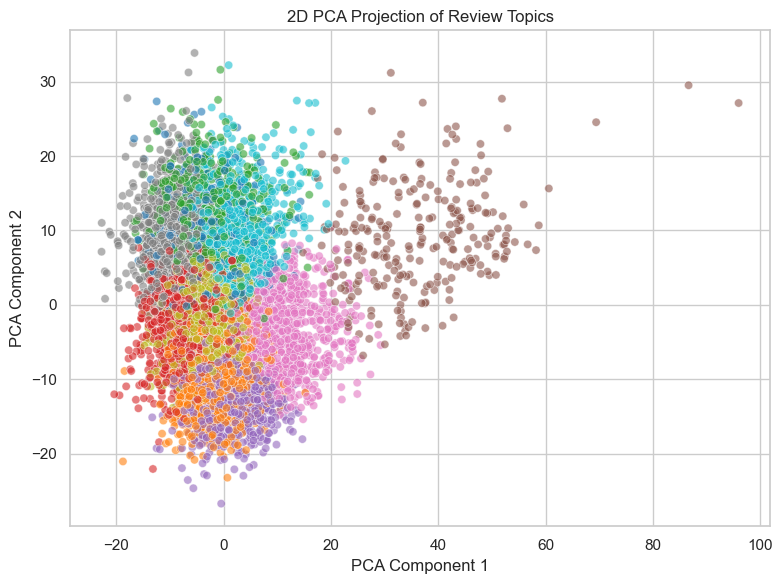

In [ ]:
# --------------------------------------------------
# 6. OPTIONAL: PCA VISUALIZATION OF TOPICS
# --------------------------------------------------
# Diagnostic visualization to inspect cluster separation

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=df_master["review_topic"],
    palette="tab10",
    alpha=0.6,
    legend=False
)
plt.title("2D PCA Projection of Review Topics")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

### PCA Interpretation

The PCA projection shows partial separation between review topics, with some overlap across clusters. This is expected due to the complexity and shared language of movie reviews. Despite overlap in two dimensions, the clustering remains meaningful in higher-dimensional space and supports the validity of the discovered topics.


## Step 1 — Feature Selection for Clustering

### What we do
We select a set of interpretable and business-relevant features that describe:
- Movie scale (production budget and runtime)
- Audience engagement (user review count and positivity)
- Critical reception (expert review count and positivity)

### Why we do it
These features capture how movies are produced and how they are received by audiences and critics.
They represent real-world characteristics that are known to influence commercial success.


In [ ]:
cluster_features = [
    "production_budget",
    "runtime",
    "user_positive_ratio",
    "expert_positive_ratio",
    "user_review_count",
    "expert_review_count"
]

# Prepare feature matrix (handle missing values safely)
X_movies = df_master[cluster_features].fillna(0).values


## Step 2 — Applying K-Means Clustering

### What we do
We apply the K-Means clustering algorithm to group movies into a fixed number of clusters.

### Why we do it
K-Means is an unsupervised learning method that identifies natural groupings in numeric data.
Clustering allows us to discover different types of movies without using box office information.


In [ ]:
from sklearn.cluster import KMeans

N_CLUSTERS = 5

movie_cluster_model = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

df_master["movie_cluster"] = movie_cluster_model.fit_predict(X_movies)

print("Movie cluster distribution:")
print(df_master["movie_cluster"].value_counts().sort_index())


Movie cluster distribution:
movie_cluster
0    5927
1     218
2     517
3    1283
4      80
Name: count, dtype: int64


## Step 3 — Clusters vs Box Office Success

### What we do
We compare the discovered movie clusters with box office success buckets.

### Why we do it
Although box office revenue was not used to create the clusters, comparing clusters with success
levels helps us evaluate whether the clusters are economically meaningful.


In [ ]:
cluster_success = (
    df_master
    .groupby(["movie_cluster", "y_bucket"])
    .size()
    .unstack(fill_value=0)
)

cluster_success_pct = cluster_success.div(
    cluster_success.sum(axis=1), axis=0
)


## Step 4 — Visualizing Cluster Success Patterns

### What we do
We visualize the relationship between movie clusters and box office success using a heatmap.

### Why we do it
The heatmap makes it easy to see which clusters are dominated by low-performing movies and which
clusters contain a higher proportion of blockbuster films.


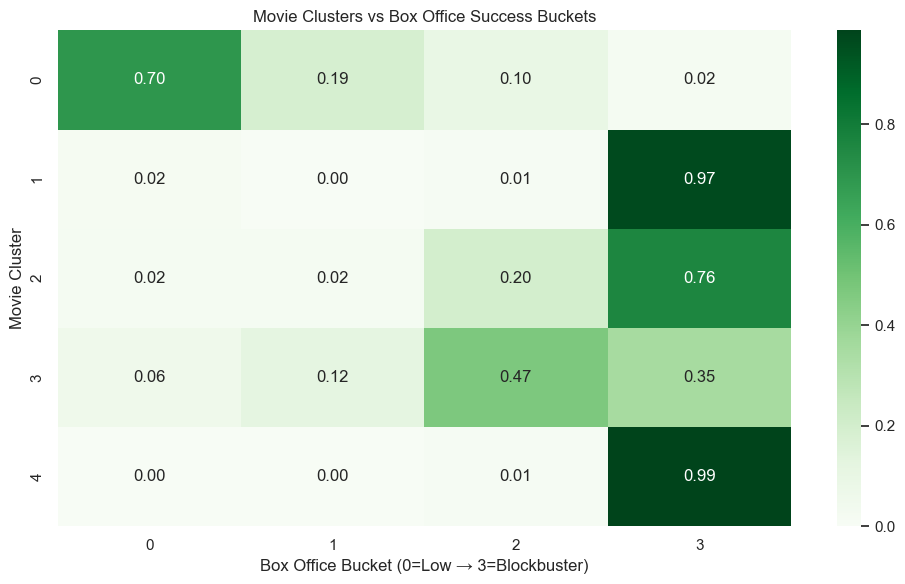

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_success_pct,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Movie Clusters vs Box Office Success Buckets")
plt.xlabel("Box Office Bucket (0=Low → 3=Blockbuster)")
plt.ylabel("Movie Cluster")
plt.tight_layout()
plt.show()


## Step 5 — Interpretation of Results

### What we observe
- Some clusters are dominated by low box office movies.
- Other clusters show a very high concentration of blockbuster films.
- This separation occurs even though box office revenue was not used during clustering.

### What this means
The clusters capture meaningful movie types based on production scale and review dynamics.
This demonstrates that movies naturally group into economically relevant categories.


## Step 6 — Optional 2D Visualization of Review Topics

### What we do
We project high-dimensional review topic embeddings into two dimensions using PCA.

### Why we do it
This visualization helps us qualitatively inspect how review topics are distributed and whether
they form distinct semantic groups.


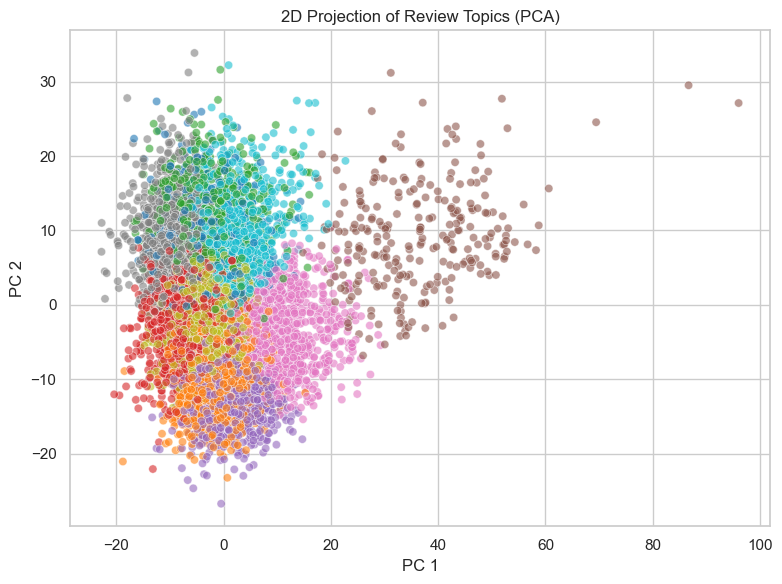

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=df_master["review_topic"],
    palette="tab10",
    alpha=0.6,
    legend=False
)
plt.title("2D Projection of Review Topics (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()


### Final Conclusion
The cluster analysis reveals that movies can be grouped into meaningful categories based on
production characteristics and review behavior. These clusters show strong alignment with box
office success levels, demonstrating that unsupervised learning can uncover economically
relevant movie types without directly using revenue data.
